In this notebook, we will showcase galactic binaries (GBs) and perform parameter estimation using simulated LISA observations. First, we will generate the synthetic data (GB signals and detector noise). Then, we run parameter estimation using Markov Chain Monte Carlo (MCMC) assuming a fixed, known noise model. Finally, we infer the parameters of the GB and the noise jointly under a simplified noise model.

This tutorial is meant as an introduction to LISA data analysis.

# Installing and Importing the Required Packages

This tutorial relies on several widely used packages with the LISA data analysis:
* `lisaorbits`: Computes spacecraft orbits and light travel times (LTTs) for the LISA constellation.
* `pytdi` & `segwo`: Construct Time-Delay Interferometry (TDI) combinations and project instrumental noise into TDI channels.
* `jaxgb`: A JAX-accelerated frequency-domain waveform generator for galactic binaries.
* `lisaconstants`: Standardized physical and astronomical constants for the LISA.
* `eryn`: An MCMC ensemble sampler featuring parallel tempering and ensemble walkers, designed for multimodal and degenerate posteriors.

In [1]:
# un-comment the next line to install the packages in google collab
# %pip install corner healpy eryn lisaorbits segwo pytdi jaxgb lisaconstants

In [1]:
# ==================== Imports ====================
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from functools import partial

import corner
import healpy as hp

# imports related to the MCMC sampler
import eryn # docs can be found at https://lisa-analysis-tools.github.io/Eryn/
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.ensemble import EnsembleSampler
from eryn.state import State

# imports related to the orbits, noise modelling, and likelihoods
from lisaorbits import EqualArmlengthOrbits
from GBEx_utils import compute_covariance, MyJaxGB, overlaid_corner

# Configure JAX for 64-bit precision (required for GW phase accuracy)
jax.config.update("jax_enable_x64", True)

print(f"JAX version: {jax.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Available devices: {jax.devices()}")


/Users/rrondeel/Code/LISA_data_analysis/gb-basics/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/rrondeel/Code/LISA_data_analysis/gb-basics/.venv/lib/python3.13/site-packages/lisaconstants/compat/astropy.py:252: UserWarning: The following constants differ between lisaconstants and the version of astropy you have installed: VACUUM_PERMEABILITY. The recommended version of astropy is 7.2.0. Use a different one at your own risks. 
You may also open an issue at https://gitlab.esa.int/lisa-sgs/commons/lisa-constants to warn that lisaconstants is not compatible with astropy v8.0.1
  warnings.warn(


JAX version: 0.11.2
NumPy version: 2.5.3
Available devices: [CpuDevice(id=0)]


# Configuring the Observation Constants

In [2]:
from lisaconstants import SIDEREALYEAR_J2000DAY

RNG_SEED = 20261006                          # Random seed for reproducible noise generation
T_OBS_DAYS = 1.0 * SIDEREALYEAR_J2000DAY   # Observation time (days)
TOBS = T_OBS_DAYS * 24 * 3600              # Observation time (seconds)
N_FREQ_BINS = 128                          # Number of frequency bins to evaluate the GB signal on
T0 = 0.0                                   # Start time (seconds)
DF = 1.0 / TOBS                            # Frequency resolution (Hz)

print(f"Observation time: {T_OBS_DAYS:.2f} days ({TOBS:.2e} seconds)")
print(f"Frequency resolution: {DF:.2e} Hz")


Observation time: 365.26 days (3.16e+07 seconds)
Frequency resolution: 3.17e-08 Hz


# Galactic Binary Model

In LISA data analysis, galactic ultracompact binaries (primarily double white dwarfs) are typically modeled as quasi-monochromatic continuous-wave sources. Below, we connect the intrinsic astrophysical properties of these systems to the parameters sampled during gravitational wave parameter estimation.

---

## Astrophysical Picture

From an astrophysical standpoint, an isolated circular binary is characterized by:

* **Component masses ($m_1, m_2$):** Often encapsulated by total mass $M = m_1 + m_2$, mass ratio $q = m_2/m_1$, or the chirp mass:

$$\mathscr{M}_c = \frac{(m_1 m_2)^{3/5}}{(m_1 + m_2)^{1/5}}$$

* **Orbital geometry & evolution:** Orbital period $P_{\rm{orb}}$ (or orbital angular frequency $\omega_{\rm{orb}} = 2\pi / P_{\rm{orb}}$) and period derivative $\dot{P}_{\rm{orb}}$ driven by gravitational radiation and/or tidal/mass-transfer interactions.
* **Spatial location:** Distance from the Solar System $d_L$, and sky position in ecliptic coordinates: latitude $\beta$ and longitude $\lambda$ (or Galactic coordinates $l, b$, or ICRS Right Ascension and Declination).
* **System orientation:** Inclination angle $\iota$ of the orbital angular momentum relative to the line of sight, and the polarization angle $\psi$.

---

## GW Observables

Over LISA’s mission lifetime, most galactic binaries exhibit very slow frequency evolution. In data analysis pipelines, the waveform is modeled by a set of **8 (or 9) parameters**:

$$\boldsymbol{\theta} = \left\{ f_0, \, \dot{f}_0, \, (\ddot{f}_0,) \, \mathscr{A}, \, \beta, \, \lambda, \, \psi, \, \iota, \, \phi_0 \right\}$$

The bridge between physical parameters and waveform observables operates across these variables:

**Initial GW Frequency ($f_0$)**

Originating as $f_0 = 2 f_{\text{orb}} = 2 / P_{\text{orb}}$ for circular quadrupole emission, this parameter sets the initial frequency of the GB in the LISA sensitivity band ($10^{-4}\text{--}10^{-1}\text{ Hz}$). Because galactic binaries radiate continuously over years, $f_0$ is among the most precisely constrained parameters in the fit.

**Frequency Derivative ($\dot{f}_0$)**

Driven predominantly by gravitational radiation reaction via $\dot{f}_{\text{GW}} = \frac{96}{5}\pi^{8/3}\left(\frac{G\mathscr{M}_c}{c^3}\right)^{5/3} f_0^{11/3}$, this term is detectable primarily in high-frequency systems ($f \gtrsim 3\text{ mHz}$). When measured, it provides a direct constraint on the chirp mass $\mathscr{M}_c$. Additionally, for interacting binaries, mass transfer can induce an astrophysical drift $\dot{f}_{\rm{astro}} < 0$ (an outspiralling effect). The observable frequency derivative combines both effects: $\dot{f}_0 = \dot{f}_{\text{GW}} + \dot{f}_{\rm{astro}}$.

**Higher-Order Frequency Drift ($\ddot{f}_0$)**

Both interacting and detached binaries have a physical $\ddot{f}_0 \neq 0$. However, its magnitude is generally too small to be resolved. Therefore, $\ddot{f}_0$ is usually excluded during parameter estimation.

**Strain Amplitude ($\mathscr{A}$) and Luminosity Distance ($d_L$)**

The characteristic gravitational-wave strain amplitude for a circular binary at quadrupole frequency $f_0 = 2 f_{\rm orb}$ is given by:

$$\mathscr{A} = \frac{2 (G\mathscr{M}_c)^{5/3} (\pi f_0)^{2/3}}{c^4 \, d_L}$$

Because $\mathscr{A} \propto \mathscr{M}_c^{5/3} / d_L$, measuring the amplitude alone leaves a complete degeneracy between chirp mass and luminosity distance. However, if $\dot{f}_0$ is also measured, $\mathscr{M}_c$ is uniquely determined, allowing the luminosity distance $d_L$ to be extracted directly:

$$d_L = \frac{2 (G\mathscr{M}_c)^{5/3} (\pi f_0)^{2/3}}{c^4 \, \mathscr{A}} = \frac{5 c}{48 \pi^2} \frac{\dot{f}_{\rm GW}}{f_0^3 \, \mathscr{A}}$$

**Sky Position ($\beta, \lambda$)**

Expressed in ecliptic latitude $\beta \in [-\pi/2, \pi/2]$ and ecliptic longitude $\lambda \in [0, 2\pi)$. Sky position is encoded through the motion of the detector constellation around the Sun, which introduces Doppler frequency modulations and antenna pattern amplitude modulations over the course of the observation.

**Polarization Angle ($\psi$) & Inclination ($\iota$)**

The polarization angle $\psi \in [0, 2\pi)$ defines the orientation of the binary's projected orbital plane on the sky, determining how signal power is partitioned across TDI channels. The inclination angle $\iota \in [0, \pi]$ governs the relative power in the two GW polarization states: $h_+ \propto 1+\cos^2\iota$ and $h_\times \propto 2 \cos\iota$.

**Initial Phase ($\phi_0$)**

The GW phase at the reference epoch $t_0$, serving as a constant phase offset that anchors the waveform's phase evolution over the observational baseline.

---

### Systematics and Degeneracies

When sampling GBs, we have to consider the following systematics:

* **Degeneracies:** In low signal-to-noise or face-on configurations, strong degeneracies emerge between $\mathscr{A}$ and $\cos\iota$. Furthermore, the quadrupolar/dipolar antenna response can yield multimodal sky solutions separated by roughly $\pi$ radians, but this degeneracy is usually broken with larger observation times. Another degeneracy is the degeneracy between $\varphi_0 → \varphi_0 + \pi$ and $\psi → \psi + \pi/2$, since these both change the sign of the signal.
* **Parameter Transformations:** Samplers typically explore reparameterized spaces, such as sampling in $\ln\mathscr{A}$, $\cos\iota$, or $\sin\phi$.

Note: it is perfectly valid to sample in  luminosity distance and chirp mass instead of amplitude and frequency derivative, but usual MCMC samplers will have a difficult time exploring the parameter space properly due to strong parameter degeneracies when the frequency derivative cannot be constrained.

In [3]:
# Transforming Astrophysical parameters to GW observables
from lisaconstants import GRAVITATIONAL_CONSTANT as G
from lisaconstants import SPEED_OF_LIGHT as c
from lisaconstants import SUN_MASS as M_SUN
from lisaconstants import PARSEC_METER as pc

def frequency_GW(Porb):
  return 2 / Porb

def frequency_derivative_from_orbital_period(Porb, Porbdot):
  return -2 * Porbdot / Porb**2

def chirp_mass(m1, m2):
  return (m1 * m2)**(3/5) / (m1 + m2)**(1/5)

def frequency_derivative_GW(f_GW, Mc):
  return 96 / 5 * np.pi**(8/3) * (G * Mc / c**3)**(5/3) * f_GW**(11/3)

def amplitude_GW(f_GW, Mc, dL):
  return 2 * (G * Mc)**(5/3) * (np.pi * f_GW)**(2/3) / (c**4 * dL)

def chirp_mass_from_GW(fdot_GW, f_GW):
  return c**3 / G * (5 / (96 * np.pi**(8/3)) * fdot_GW / f_GW **(11/3))**(3/5)

def distance_from_GW(fdot_GW, f_GW, A_GW):
  return 5 * c / (48 * np.pi**2) * fdot_GW  / (f_GW**3 * A_GW)


Some interesting binaries to look at. Can you figure out why they are interesting?

| System / Target | Type | $f_0$ (mHz) | $\dot{f}$ ($10^{-17}\text{ Hz s}^{-1}$) | $\mathscr{A}$ ($10^{-23}$) | $\cos\iota$ | $m_1$ ($M_\odot$) | $m_2$ ($M_\odot$) | $\mathscr{M}_c$ ($M_\odot$) | $d_L$ (kpc) | $\lambda$ (rad) | $\beta$ (rad) | $\psi$ (rad) | $\phi_0$ (rad) |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| **HM Cnc** | AM CVn | 6.220| 72.5 | 4.22 | 0.79 | 0.55 | 0.27 | 0.33 | 7.50 | 2.10 | -0.08 | 2.35 | 5.79 |
| **ZTFJ1539** | DWD | 4.822 | 27.6 | 9.23 | 0.10 | 0.61 | 0.21 | 0.30 | 2.47| 3.58 | +1.15 | 5.97 | 0.56 |
| **SDSSJ0651** | DWD | 2.614 | 3.35 | 15.79| 0.05 | 0.49 | 0.25 | 0.30 | 0.96 | 1.77 | +0.10 | 0.98 | 2.44 |
| **CDm3011223** | sdB | 0.473 | 0.015 | 39.27 | 0.12 | 0.79 | 0.54 | 0.57 | 0.36 | 3.86 | -0.29 | 4.30 | 3.53 |
| **ESCet** | sdB | 3.225 | -1.66 | 9.26 | 0.50 | 0.80 | 0.16 | 0.29 | 1.78 | 0.43 | -0.35 | 0.98 | 2.04 |
| **Synthetic 1** | Benchmark | 3.500 | 2.00 | 8.77 | 1.00 | 0.35 | 0.35 | 0.30 | 2.10 | 1.00 | +1.40 | 0.50 | 1.20 |
| **Synthetic 2** | Benchmark | 3.500 | 2.00 | 8.77 | 0.50 | 0.35 | 0.35 | 0.30 | 2.10 | 2.50 | 0.05 | 0.80 | 0.50 |


In [4]:
# these values are for the verification binary named HM Cnc
injection_source_params = np.array([
    6.220e-3,                    # f0 (Hz)
    72.5e-17,                    # fdot (Hz/s) - rapid frequency evolution
    4.22e-23,                    # amplitude (strain)
    -0.08,                       # ecliptic latitude (rad)
    2.10,                        # ecliptic longitude (rad)
    2.35,                        # polarization (rad)
    0.663,                       # inclination (rad)
    5.79,                        # initial phase (rad)
])

In [5]:
np.arccos(0.5)

np.float64(1.0471975511965976)

# Waveform Generation with JaxGB and TDI 2.0

We will be using a modified version of JaxGB to generate the signal templates of a GB. This package is the DDPC standard and is used by the Gee-Moo global fit pipeline. There are other widely used packages to generate GB signal templates. Examples are GBGPU, FastGB, and eGB-multi. The initial version of GBGPU and JaxGB are based on the fast frequency domain signal generation methods of FastGB. However, recently developers are improving these packages to include more realism into the signal templates. For example, eGB-multi is a package based on JaxGB, specifically designed for eccentric galactic binaries.

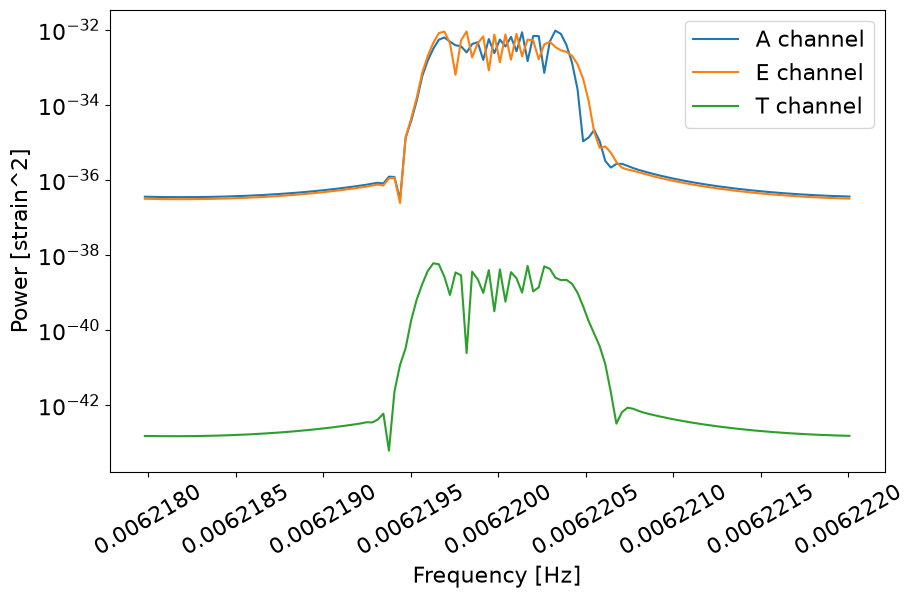

In [6]:
# initialise orbits
orbits = EqualArmlengthOrbits()

# initialise GB signal generator
jaxgb = MyJaxGB(orbits=orbits, t_obs=TOBS, t0=T0, n=N_FREQ_BINS, tdi_generation=2.0, tdi_combination="AET")

# calculate minimal frequency of the GB ((f0 * (TOBS) - N_FREQ_BINS / 2) * DF)
kmin = int(np.array(jaxgb.get_kmin(injection_source_params[0])))
kmax = kmin + jaxgb.n
freqs = DF * (np.arange(N_FREQ_BINS) + kmin)

# calculating and plotting A, E, T strain
A_inj, E_inj, T_inj = jaxgb.get_tdi(jnp.array(injection_source_params), tdi_generation=2.0, tdi_combination="AET")

plt.figure(figsize=(10,6))
plt.semilogy(freqs, np.abs(A_inj)**2, label="A channel")
plt.semilogy(freqs, np.abs(E_inj)**2, label="E channel")
plt.semilogy(freqs, np.abs(T_inj)**2, label="T channel")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power [strain^2]")
plt.xticks(rotation=30)
plt.legend()
plt.show()


# Noise Model: The Orthogonal AET Basis

In this tutorial, we will consider the AET TDI channel basis. Because we are assuming that the orbits have equal and unchanging armlengts, this TDI channel basis is an orthogonal basis, i.e., the off-diagnonal entries of the covariance matrix, AE, AT, and ET, can be neglegted (making the calculations easier, faster, and memory efficient). In reality, LISA's orbits are unequal and changing, thus this assumption would not hold. As we will see below, even the equal armlength orbits are not perfectly equal and stationary, but the variance from this assumption is small enough to be ignored.

Covariance shape: (10, 1000, 3, 3)


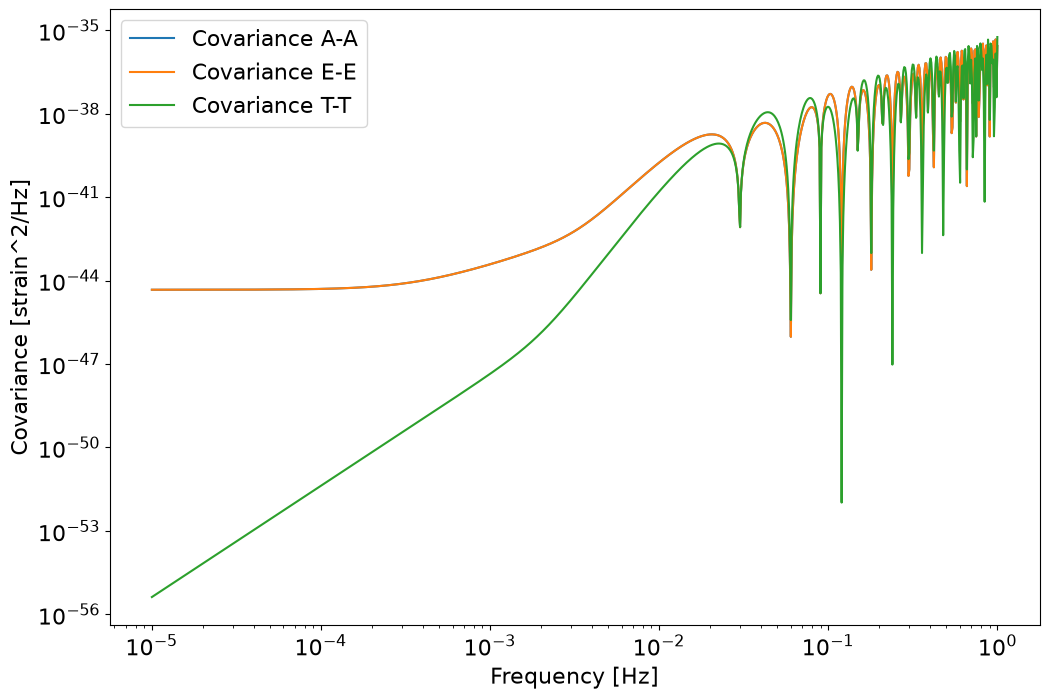

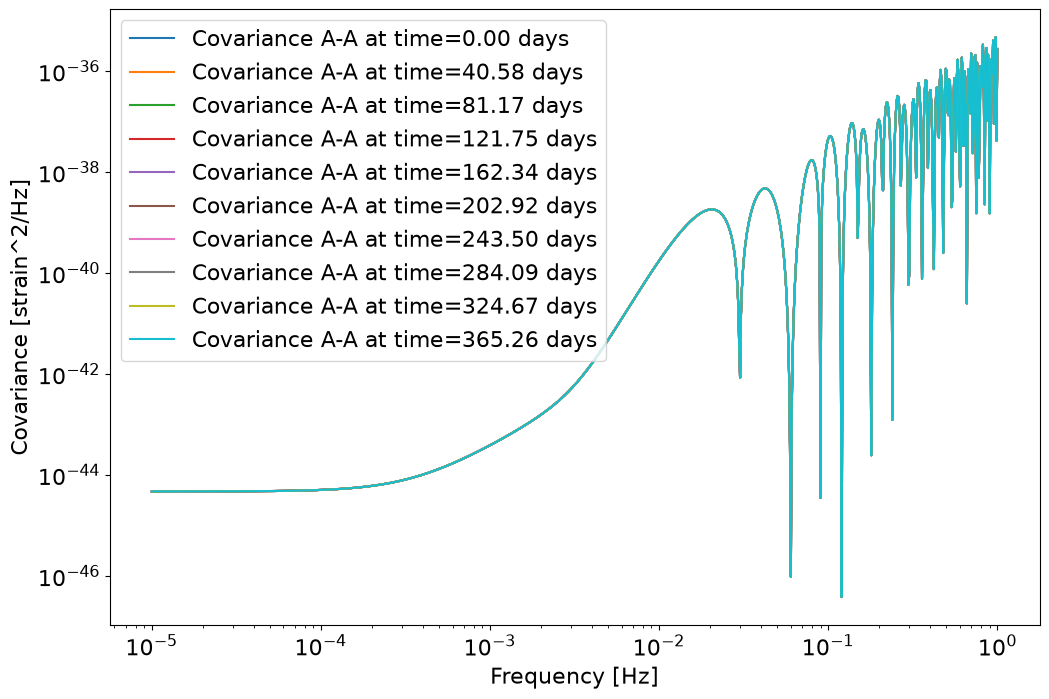

In [7]:
frequency_array = jnp.logspace(-5, 0, 1000)
time_array = jnp.linspace(T0, T0+TOBS, 10)
ltts = orbits.compute_ltt(time_array)
cov = compute_covariance(frequency_array, ltts)

# Note: taking the mean across time samples
cov_AET = compute_covariance(freqs, ltts).mean(axis=0)

inv_cov_AET = np.linalg.inv(cov_AET)
print(f"Covariance shape: {cov.shape}")

ind_time = 0
plt.figure(figsize=(12,8))
plt.loglog(frequency_array, np.abs(cov[ind_time, :, 0, 0]), label="Covariance A-A")
plt.loglog(frequency_array, np.abs(cov[ind_time, :, 1, 1]), label="Covariance E-E")
plt.loglog(frequency_array, np.abs(cov[ind_time, :, 2, 2]), label="Covariance T-T")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Covariance [strain^2/Hz]")
plt.legend()
plt.show()

plt.figure(figsize=(12,8))

for i, time in enumerate(time_array):
    plt.loglog(frequency_array, np.abs(cov[i, :, 0, 0]), label=f"Covariance A-A at time={time/(86400):.2f} days")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Covariance [strain^2/Hz]")
plt.legend()
plt.show()

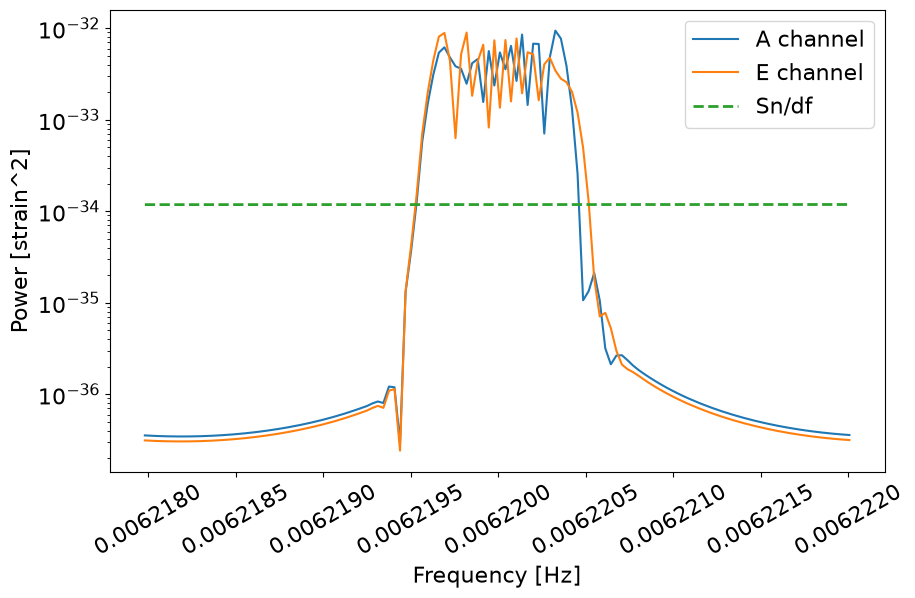

In [8]:
plt.figure(figsize=(10,6))
plt.plot(freqs, np.abs(A_inj)**2, label="A channel")
plt.plot(freqs, np.abs(E_inj)**2, label="E channel")
plt.semilogy(freqs, np.abs(cov_AET[:, 0, 0])/DF/4, label="Sn/df", linestyle="--", linewidth=2)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power [strain^2]")
plt.xticks(rotation=30)
plt.legend()
plt.show()


### Verifying Noise Orthogonality: Covariance and Inverse Covariance

To verify that the $A, E, T$ basis is orthogonal, we inspect both the noise covariance matrix $\mathbf{Cov}(f)$ (the cross-spectral density matrix) and its inverse $\mathbf{Cov}^{-1}(f)$:

* **$\mathbf{Cov}(f)$:** The off-diagonal entries ($AE, AT, ET$) are suppressed by many orders of magnitude relative to the auto-power diagonal entries ($AA, EE$), demonstrating cross-channel decorrelation.
* **$\mathbf{Cov}^{-1}(f)$:** The precision matrix is also diagonally dominant.

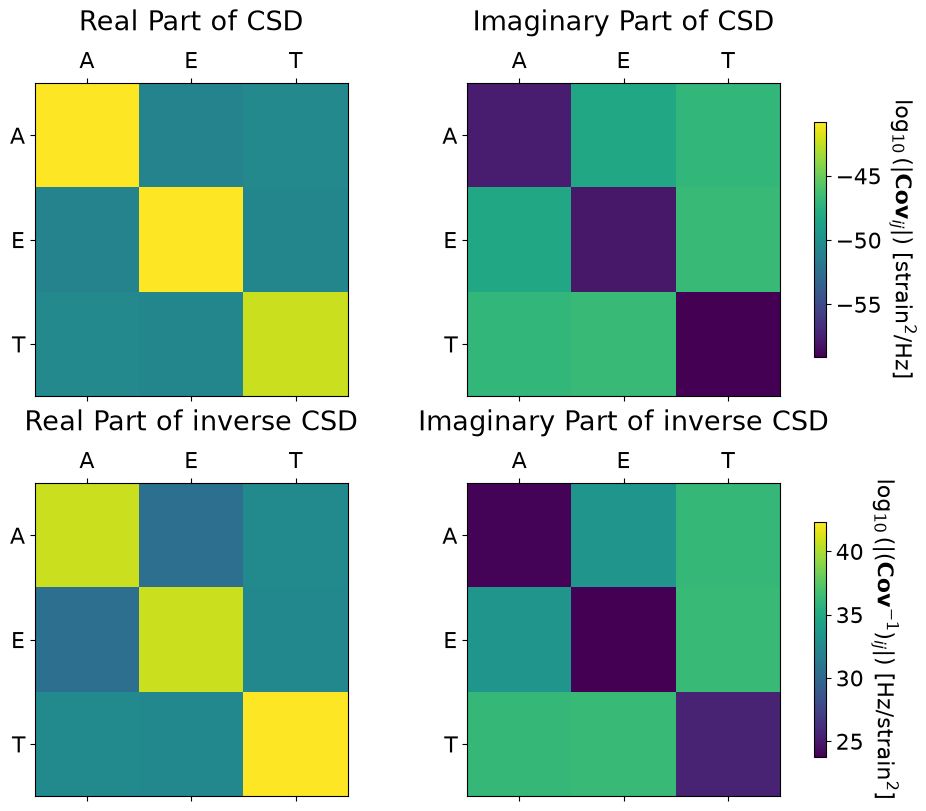

In [9]:
# Check the structure of both the covariance and inverse covariance matrices across AET channels
cov_real = np.log10(np.abs(cov_AET[0].real))
cov_imag = np.log10(np.abs(cov_AET[0].imag))

inv_cov_real = np.log10(np.abs(inv_cov_AET[0].real))
inv_cov_imag = np.log10(np.abs(inv_cov_AET[0].imag))

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
channels = ["A", "E", "T"]

# Plot Covariance (top row)
vmin_cov = min(np.nanmin(cov_real), np.nanmin(cov_imag))
vmax_cov = max(np.nanmax(cov_real), np.nanmax(cov_imag))

mat00 = axes[0, 0].matshow(cov_real, cmap="viridis", vmin=vmin_cov, vmax=vmax_cov)
axes[0, 0].set_title(r"Real Part of CSD", pad=15)
mat01 = axes[0, 1].matshow(cov_imag, cmap="viridis", vmin=vmin_cov, vmax=vmax_cov)
axes[0, 1].set_title(r"Imaginary Part of CSD", pad=15)

cbar0 = fig.colorbar(mat00, ax=axes[0, :], shrink=0.75, pad=0.04)
cbar0.set_label(r"$\log_{10}(|\mathbf{Cov}_{ij}|)$ [strain$^2$/Hz]", rotation=270, labelpad=25)

# Plot Inverse Covariance (bottom row)
vmin_inv = min(np.nanmin(inv_cov_real), np.nanmin(inv_cov_imag))
vmax_inv = max(np.nanmax(inv_cov_real), np.nanmax(inv_cov_imag))

mat10 = axes[1, 0].matshow(inv_cov_real, cmap="viridis", vmin=vmin_inv, vmax=vmax_inv)
axes[1, 0].set_title(r"Real Part of inverse CSD", pad=15)
mat11 = axes[1, 1].matshow(inv_cov_imag, cmap="viridis", vmin=vmin_inv, vmax=vmax_inv)
axes[1, 1].set_title(r"Imaginary Part of inverse CSD", pad=15)

cbar1 = fig.colorbar(mat10, ax=axes[1, :], shrink=0.75, pad=0.04)
cbar1.set_label(r"$\log_{10}(|(\mathbf{Cov}^{-1})_{ij}|)$ [Hz/strain$^2$]", rotation=270, labelpad=25)

for ax in axes.flat:
    ax.set_xticks(range(len(channels)))
    ax.set_yticks(range(len(channels)))
    ax.set_xticklabels(channels)
    ax.set_yticklabels(channels)

plt.show()

# Generating Synthetic Data: Signal + Colored Noise

To simulate realistic LISA observations, we inject a single realization of correlated, colored noise into the synthetic TDI channels.

Because the one-sided Power Spectral Density $S_n(f)$ is defined per unit frequency, the variance of the complex noise in each discrete Fourier bin of width $\Delta f$ is given by:

$$\sigma_k^2 = \frac{S_n(f_k)}{4 \Delta f}$$

We draw a multi-channel colored noise realization $\boldsymbol{n}_k$ from the covariance matrix $\mathbf{Cov}(f_k)$ via Cholesky decomposition:

$$\boldsymbol{n}_k = \mathbf{L}_k \boldsymbol{z}_k, \quad \text{where} \quad \mathbf{L}_k \mathbf{L}_k^H = \frac{\mathbf{Cov}(f_k)}{4\Delta f} \quad \text{and} \quad \boldsymbol{z}_k \sim \mathscr{CN}(\mathbf{0}, \mathbf{I}_3)$$

Adding this noise draw to the injected Galactic Binary template yields the simulated data vector $\boldsymbol{d} = \boldsymbol{h}(\boldsymbol{\theta}_{\mathrm{true}}) + \boldsymbol{n}$ analyzed in the parameter estimation sections below. For the equal armlength orbits, the correlations between frequency bins is insignificant, ensuring that our likelihood computations are diagonal (a simple sum over frequencies). However, for non-stationary (realistic) orbits, these correlations can be significant depending on the signal morphology, motivating a switch to time-frequency domain analyses.

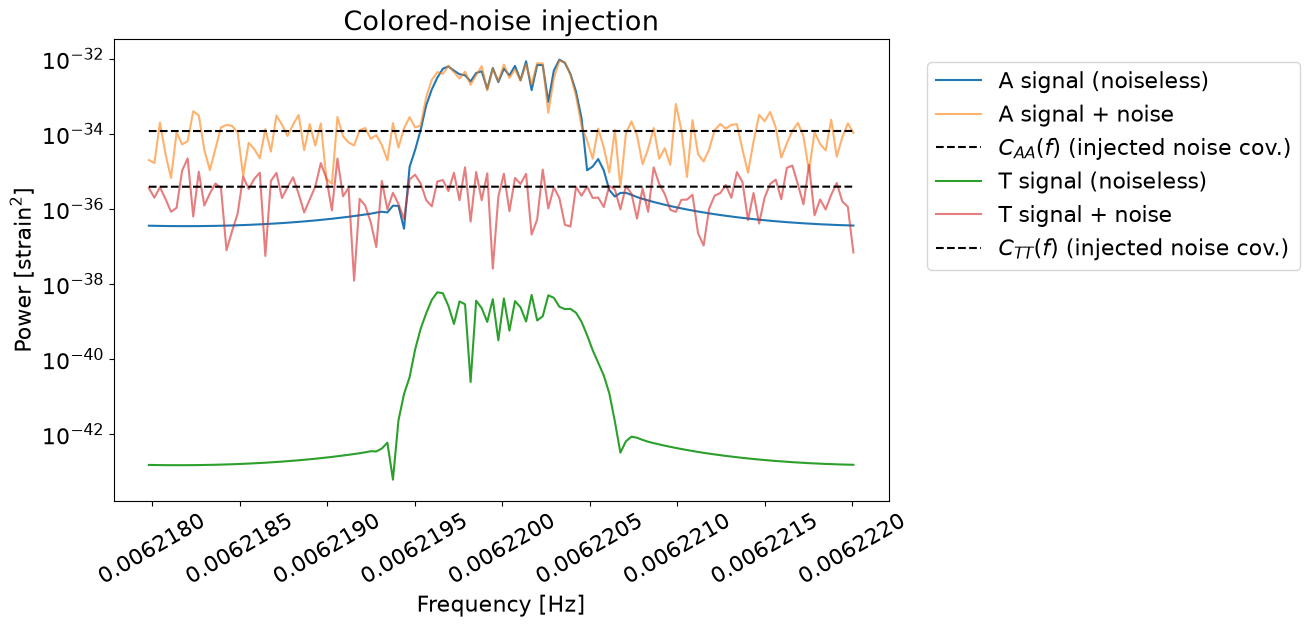

sigma0 (from covariance, A/E/T):         [1.08726420e-17 1.08726420e-17 1.97078936e-18]
sigma_empirical (from this noise draw):  [1.04845598e-17 1.08379512e-17 1.96708661e-18]
expected relative scatter between the variance of the draw and analytical variance --> ~ 1/sqrt(N_FREQ_BINS) = 8.8%


In [10]:
rng = np.random.default_rng(RNG_SEED)

# draw a random, complex vector
z = (rng.standard_normal((N_FREQ_BINS, 3)) + 1j * rng.standard_normal((N_FREQ_BINS, 3))) / np.sqrt(2) 
L_AET = np.linalg.cholesky(cov_AET / (DF * 4))
noise_AET = np.einsum("kij,kj->ki", L_AET, z)

noise_A, noise_E, noise_T = noise_AET[:, 0], noise_AET[:, 1], noise_AET[:, 2]
A_noisy, E_noisy, T_noisy = A_inj + noise_A, E_inj + noise_E, T_inj + noise_T
d_noise_only = np.stack([noise_A, noise_E, noise_T], axis=0)
d_noisy = np.stack([A_noisy, E_noisy, T_noisy], axis=0)

plt.figure(figsize=(10,6))
plt.semilogy(freqs, np.abs(A_inj) ** 2, label="A signal (noiseless)")
plt.semilogy(freqs, np.abs(A_noisy) ** 2, alpha=0.6, label="A signal + noise")
plt.semilogy(freqs, np.abs(cov_AET[:, 0, 0]).real / (DF * 4), "--", color="k", label=r"$C_{AA}(f)$ (injected noise cov.)")
plt.semilogy(freqs, np.abs(T_inj) ** 2, label="T signal (noiseless)")
plt.semilogy(freqs, np.abs(T_noisy) ** 2, alpha=0.6, label="T signal + noise")
plt.semilogy(freqs, np.abs(cov_AET[:, 2, 2]).real / (DF * 4), "--", color="k", label=r"$C_{TT}(f)$ (injected noise cov.)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power [strain$^2$]")
plt.legend(loc=[1.05, 0.5])
plt.title("Colored-noise injection")
plt.xticks(rotation=30)
plt.show()

# Reference sigma per channel: sqrt of the mean covariance diagonal across the band
sigma0 = np.sqrt(np.array([cov_AET[:, i, i].mean().real / (DF * 4) for i in range(3)]))
sigma_empirical = np.sqrt(np.mean(np.abs(noise_AET) ** 2, axis=0))
print("sigma0 (from covariance, A/E/T):        ", sigma0)
print("sigma_empirical (from this noise draw): ", sigma_empirical)
print(f"expected relative scatter between the variance of the draw and analytical variance --> ~ 1/sqrt(N_FREQ_BINS) = {1 / np.sqrt(N_FREQ_BINS):.1%}")


## Setting up the initial data and sampling basis

In [11]:
# Extract the diagonal components of the noise CSD / PSD: S_{n, X}(f)
psd_AET_diag = np.stack([cov_AET[:, 0, 0].real, cov_AET[:, 1, 1].real, cov_AET[:, 2, 2].real], axis=-1)
inv_psd_AET_diag = 1.0 / psd_AET_diag

# sampling choice: number of walkers (MCMC chains), number of temperatures used for parallel tempering
NWALKERS, NTEMPS = 32, 8

# injection data is the true signal template for the selected binary
d_inj = np.stack([A_inj, E_inj, T_inj], axis=0)

# In what basis do we want to sample the GB parameters?
# Set to True to sample in (f0, fdot, lnA, sin(beta), lambda, psi, cos(iota), phi0)
# Set to False to sample in standard parameters (f0, fdot, A, beta, lambda, psi, iota, phi0)
USE_TRANSFORMED_PARAMS = False


def params_to_physical(params, use_transformed=False):
    """
    Convert sampling parameters to physical parameters for waveform generation.
    If use_transformed is True:
        index 2: ln(A) -> A = exp(lnA)
        index 3: sin(beta) -> beta = arcsin(sin_beta)
        index 6: cos(iota) -> iota = arccos(cos_iota)
    """
    if not use_transformed:
        return params
    p_phys = params.copy()
    p_phys = p_phys.at[..., 2].set(jnp.exp(params[..., 2]))
    p_phys = p_phys.at[..., 3].set(jnp.arcsin(jnp.clip(params[..., 3], -1.0, 1.0)))
    p_phys = p_phys.at[..., 6].set(jnp.arccos(jnp.clip(params[..., 6], -1.0, 1.0)))
    return p_phys

def physical_to_sampling(params_phys, use_transformed=False):
    """
    Convert physical parameters to sampling parameters.
    If use_transformed is True:
        index 2: A -> ln(A)
        index 3: beta -> sin(beta)
        index 6: iota -> cos(iota)
    """
    if not use_transformed:
        return np.asarray(params_phys)
    p_samp = np.array(params_phys, copy=True)
    p_samp[..., 2] = np.log(params_phys[..., 2])
    p_samp[..., 3] = np.sin(params_phys[..., 3])
    p_samp[..., 6] = np.cos(params_phys[..., 6])
    return p_samp

def get_parameter_labels(use_transformed=False, include_noise=False):
    """Return LaTeX parameter labels for corner plots."""
    if use_transformed:
        labels = [
            r"$f_0$ [Hz]", r"$\dot f_0$ [Hz/s]", r"$\ln A$", r"$\sin\beta$",
            r"$\lambda$", r"$\psi$", r"$\cos\iota$", r"$\phi_0$"
        ]
    else:
        labels = [
            r"$f_0$ [Hz]", r"$\dot f_0$ [Hz/s]", r"$A$", r"$\beta$",
            r"$\lambda$", r"$\psi$", r"$\iota$", r"$\phi_0$"
        ]
    if include_noise:
        labels += [r"$\sigma_A$", r"$\sigma_E$", r"$\sigma_T$"]
    return labels

# setting up the batches for vectorized / batched likelihood evaluations
BATCH_SIZE = NTEMPS * NWALKERS
d_noisy_batch = jnp.repeat(jnp.asarray(d_noisy)[None, :, :], BATCH_SIZE, axis=0)
true_sampling_params = physical_to_sampling(injection_source_params, use_transformed=USE_TRANSFORMED_PARAMS)
test_params = np.repeat(np.asarray(true_sampling_params)[None, :], BATCH_SIZE, axis=0)
temp_params = np.zeros((BATCH_SIZE, injection_source_params.shape[0]))

## Likelihood and MCMC Parameter Estimation

Assuming stationary Gaussian noise, the frequency-domain matched-filtering log-likelihood for residual vector $\boldsymbol{r}(\boldsymbol{\theta}) = \boldsymbol{d} - \boldsymbol{h}(\boldsymbol{\theta})$ is defined via the noise-weighted inner product:

$$\ln \mathcal{L}(\boldsymbol{\theta}) = -\frac{1}{2} \langle \boldsymbol{r}(\boldsymbol{\theta}) \mid \boldsymbol{r}(\boldsymbol{\theta}) \rangle = - 2 \Delta f \sum_{X \in \{A, E, T\}} \sum_k \frac{|\tilde{r}_X(f_k; \boldsymbol{\theta})|^2}{S_{n, X}(f_k)}$$

where $\tilde{r}_X(f_k; \boldsymbol{\theta}) = \tilde{d}_X(f_k) - \tilde{h}_X(f_k; \boldsymbol{\theta})$ is the frequency-domain residual for channel $X \in \{A,E,T\}$ at frequency bin $f_k$, and $S_{n, X}(f_k)$ is the corresponding one-sided noise power spectral density.

Because the equal-arm $A, E, T$ basis is orthogonal, cross-channel covariance terms can be neglected, allowing the likelihood to be evaluated as an independent sum over the $A, E,$ and $T$ channels. For a fixed noise model, the determinant normalization $\ln |\mathbf{Cov}|$ is a constant independent of $\boldsymbol{\theta}$ and is omitted.

In [12]:
def inner_product(d1, d2, inv_psd):
    """Noise-weighted inner product: 4 Re[d1* . S^-1 . d2] df.
    Supports both single signals (3, N_freq) and batched signals (..., 3, N_freq).
    """
    # Ensure inv_psd is shaped (3, N_freq) to align with channels on axis -2
    if inv_psd.ndim == 2 and inv_psd.shape[0] != 3 and inv_psd.shape[-1] == 3:
        inv_psd = inv_psd.T
    return 4.0 * DF * jnp.sum((d1.conj() * d2 * inv_psd).real, axis=(-2, -1))

# JaxGB uses JAX to accelerate the calculations. While JAX is very good at this aceleration, it can sometimes be annoying to optimize your code such that
# the aceleration features do not silently break. One of these features is Just-In-Time (JIT) compilation of the code. JIT allows us to compile the code once,
# before we heavily use the function (for custom written python functions python compile the code every time it is called).
@partial(jax.jit, static_argnames=("kmin", "kmax", "tdi_generation", "tdi_combination", "use_transformed"))
def jit_ll_csd_diag(params, data, inv_psd, kmin, kmax, tdi_generation, tdi_combination, use_transformed=False):
    """Batched log-likelihood using inner_product: ln L = -1/2 <r | r>."""
    phys_params = params_to_physical(params, use_transformed)
    residual = jaxgb.get_data_minus_template(
        phys_params,
        data,
        kmin,
        kmax,
        tdi_generation=tdi_generation,
        tdi_combination=tdi_combination,
    )
    # ln L = -1/2 <r | r>
    return -0.5 * inner_product(residual, residual, inv_psd)

def likelihood(params, inv_psd, data, temp_params=None, use_transformed=False):
    """Vectorized likelihood wrapper compatible with Eryn and ad-hoc calls."""
    params_2d = jnp.atleast_2d(params)
    
    # Broadcast single data (3, N_freq) to batch if needed
    if data.ndim == 2:
        data = jnp.broadcast_to(data[None, :, :], (params_2d.shape[0], *data.shape))
    elif data.shape[0] != params_2d.shape[0]:
        data = jnp.broadcast_to(data[:1], (params_2d.shape[0], *data.shape[1:]))
    
    lls = jit_ll_csd_diag(
        params_2d,
        data,
        inv_psd,
        kmin,
        kmax,
        tdi_generation=2.0,
        tdi_combination="AET",
        use_transformed=use_transformed,
    )
    return np.asarray(lls)


# Warm up JIT compilation
import time

start_time = time.time()
_ = likelihood(np.asarray(temp_params), inv_psd_AET_diag, d_noisy_batch, temp_params, use_transformed=USE_TRANSFORMED_PARAMS)
print(f"jit_ll compiled and warmed up in {time.time() - start_time:.2f} s")

# Compute optimal and matched-filter SNR using inner_product
SNR_injection = inner_product(d_inj, d_inj, inv_psd_AET_diag)**0.5
SNR_injection_MF = inner_product(d_noisy, d_inj, inv_psd_AET_diag)**0.5
print("Injected SNR (optimal):", SNR_injection)
print("Injected SNR (matched-filter on noisy data):", SNR_injection_MF)


jit_ll compiled and warmed up in 0.25 s
Injected SNR (optimal): 44.87561394791411
Injected SNR (matched-filter on noisy data): 44.740290789546435


### Template Verification and Baseline Likelihood

Before launching the MCMC sampler, we verify the template generation and likelihood:
1. **Waveform Mismatch:** We compute the normalized mismatch $1 - \frac{\langle h_1 \mid h_2 \rangle}{\sqrt{\langle h_1 \mid h_1 \rangle \langle h_2 \mid h_2 \rangle}}$ between the reconstructed template and the injection at true parameters, confirming numerical consistency (mismatch $\approx 0$).
2. **Baseline Log-Likelihood:** We evaluate the log-likelihood at the injection parameters on the noisy data to establish the reference log-likelihood near the posterior peak.

In [13]:
def mismatch(h1, h2, inv_psd):
  h1h2 = inner_product(h1, h2, inv_psd)
  h1h1 = inner_product(h1, h1, inv_psd)
  h2h2 = inner_product(h2, h2, inv_psd)
  return float(1.0 - h1h2 / np.sqrt(h1h1 * h2h2))

# calculate the mismatch
A_check, E_check, T_check = jaxgb.get_tdi(jnp.array(injection_source_params), tdi_generation=2.0, tdi_combination="AET")
d_check = np.stack([A_check, E_check, T_check], axis=0)
print("Mismatch (nonrel template, true params):", mismatch(d_check, d_inj, inv_psd_AET_diag))

# check that the likelihood of the injection on noisy data
ll_inj = likelihood(jnp.atleast_2d(true_sampling_params), inv_psd_AET_diag, d_noisy_batch, test_params, use_transformed=USE_TRANSFORMED_PARAMS)
print(f"Loglike at true params:   {ll_inj[0]:.2f}")

Mismatch (nonrel template, true params): 0.0
Loglike at true params:   -186.88


### Prior Setup

In Bayesian parameter estimation, the prior $p(\boldsymbol{\theta})$ encapsulates our astrophysical knowledge and constraints before evaluating the likelihood:
* **Frequency ($f_0$):** We set a uniform prior over a narrow window of half-width $1\,\mu\text{Hz}$ around $f_0$. Because the quasi-monochromatic signals stay in-band for the full observation time, the obtained precision on $f_0$ is $\sim 1/T_{\rm obs} \approx 3 \times 10^{-8}\text{ Hz}$. A blind MCMC run will have a difficult time exploring the full frequency range. In practice, parameter estimation is performed *after* a search pipeline has localized the candidate.
* **Frequency Derivative ($\dot{f}_0$):** Bound within $[-10^{-16}, 10^{-15}]\text{ Hz/s}$, accommodating both gravitational radiation reaction ($\dot{f}_{\rm GW} > 0$) and astrophysical mass transfer ($\dot{f}_{\rm astro} < 0$, such as in outspiraling AM CVn systems).
* **Strain Amplitude ($\mathscr{A}$):** Bound within $[A_0 / 4, 4 A_0]$ (or $[\ln(A_0/4), \ln(4A_0)]$ in transformed space), chosen to bracket the detected source.
* **Sky Location & Orientation:** Uniform priors over $\sin\beta \in [-1, 1]$ (isotropic sky) and $\cos\iota \in [-1, 1]$ (isotropic orientation), with periodic uniform priors $[0, 2\pi)$ for longitude $\lambda$, polarization $\psi$, and initial phase $\phi_0$.

In [14]:
def setup_priors(f0_center, f0_width, A_center=1e-18, use_transformed=False):
    """Set up prior distributions for galactic binary parameters.
    
    Parameters
    ----------
    f0_center : float
        Central frequency (Hz).
    f0_width : float
        Prior half-width in frequency (Hz).
    A_center : float
        Reference amplitude for prior bounds.
    use_transformed : bool, default=False
        If True, sample in (f0, fdot, lnA, sin(beta), lambda, psi, cos(iota), phi0).
        If False, sample in (f0, fdot, A, beta, lambda, psi, iota, phi0).
    """

    # Amplitude bounds (based on SNR considerations)
    min_A = A_center / 4  # Very faint
    max_A = A_center * 4  # Very bright

    # Frequency derivative bounds
    fdot_max = 1e-15  # Hz/s
    fdot_min = -1e-16    # Hz/s

    # Frequency bounds
    f_min = f0_center - f0_width
    f_max = f0_center + f0_width

    if use_transformed:
        priors = {
            "gb": ProbDistContainer({
                0: uniform_dist(f_min, f_max),                       # f0
                1: uniform_dist(fdot_min, fdot_max),                 # fdot
                2: uniform_dist(np.log(min_A), np.log(max_A)),       # ln(A)
                3: uniform_dist(-1.0, 1.0),                          # sin(beta)
                4: uniform_dist(0.0, 2 * np.pi),                     # lambda
                5: uniform_dist(0.0, 2 * np.pi),                     # psi
                6: uniform_dist(-1.0, 1.0),                          # cos(iota)
                7: uniform_dist(0.0, 2 * np.pi),                     # phi0
            })
        }
        bounds = [
            (f_min, f_max),
            (fdot_min, fdot_max),
            (np.log(min_A), np.log(max_A)),
            (-1.0, 1.0),
            (0.0, 2 * np.pi),
            (0.0, 2 * np.pi),
            (-1.0, 1.0),
            (0.0, 2 * np.pi),
        ]
    else:
        priors = {
            "gb": ProbDistContainer({
                0: uniform_dist(f_min, f_max),                       # f0
                1: uniform_dist(fdot_min, fdot_max),                 # fdot
                2: uniform_dist(min_A, max_A),                       # amplitude
                3: uniform_dist(-np.pi/2, np.pi/2),                  # beta
                4: uniform_dist(0.0, 2 * np.pi),                     # lambda
                5: uniform_dist(0.0, 2 * np.pi),                     # psi
                6: uniform_dist(0.0, np.pi),                         # iota
                7: uniform_dist(0.0, 2 * np.pi),                     # phi0
            })
        }
        bounds = [
            (f_min, f_max),
            (fdot_min, fdot_max),
            (min_A, max_A),
            (-np.pi/2, np.pi/2),
            (0.0, 2 * np.pi),
            (0.0, 2 * np.pi),
            (0.0, np.pi),
            (0.0, 2 * np.pi),
        ]

    # Periodic parameters
    periodic = {
        "gb": {
            4: 2 * np.pi,  # lambda
            5: 2 * np.pi,  # psi
            7: 2 * np.pi,  # phi0
        }
    }

    ndims = 8  # Number of parameters per source

    print(f"\nPrior bounds (use_transformed={use_transformed}):")
    if use_transformed:
        print(f"  ln(A): [{np.log(min_A):.2f}, {np.log(max_A):.2f}]")
        print(f"  sin(beta): [-1.0, 1.0]")
        print(f"  cos(iota): [-1.0, 1.0]")
    else:
        print(f"  A: [{min_A:.2e}, {max_A:.2e}]")
        print(f"  beta: [-pi/2, pi/2]")
        print(f"  iota: [0, pi]")
    print(f"  f0: [{f_min:.6e}, {f_max:.6e}] Hz")
    print(f"  fdot: [{fdot_min:.2e}, {fdot_max:.2e}] Hz/s")

    return priors, periodic, ndims, bounds

priors, periodic, ndims, bounds = setup_priors(injection_source_params[0], 1e-6, A_center=injection_source_params[2], use_transformed=USE_TRANSFORMED_PARAMS)



Prior bounds (use_transformed=False):
  A: [1.06e-23, 1.69e-22]
  beta: [-pi/2, pi/2]
  iota: [0, pi]
  f0: [6.219000e-03, 6.221000e-03] Hz
  fdot: [-1.00e-16, 1.00e-15] Hz/s


# Running the MCMC Sampler

We sample the posterior distribution using `eryn`'s ensemble sampler with parallel tempering:
* **Ensemble Walkers (32 walkers):** Affine-invariant ensemble sampling allows walkers to explore correlated degeneracies efficiently.
* **Parallel Tempering (8 temperatures):** Higher-temperature chains flatten the likelihood surface ($\mathcal{L}^{1/T}$), allowing walkers to jump across likelihood barriers and explore multimodal sky reflection modes. Only samples from the coldest chain ($T = 1$) represent the true posterior distribution.
* **Initialization:** Walkers are initialized in a tight cluster (`rel_scatter = 1e-4`) around the true candidate parameters, simulating the parameter estimation stage following a detection pipeline.

*Note on NumPy 2.x Compatibility:* Depending on your installed `eryn` and `numpy` versions, you may encounter an `AttributeError` regarding `np.in1d`. In NumPy 2.x, `np.in1d` is superseded by `np.isin`. If this occurs, updating `np.in1d` to `np.isin` inside `eryn/ensemble.py` resolves the issue.

In [15]:
# Create sampler
sampler = EnsembleSampler(
    NWALKERS,
    ndims,
    likelihood,
    priors,
    branch_names=["gb"],
    args=(inv_psd_AET_diag, d_noisy_batch, temp_params, USE_TRANSFORMED_PARAMS),
    tempering_kwargs=dict(ntemps=NTEMPS),
    periodic=periodic,
    vectorize=True,
)

# Initialize state: start all parameters around the truth across all temperatures and walkers
print("\nInitializing sampler state...")

start_points = {
    "gb": np.zeros((NTEMPS, NWALKERS, 1, ndims))
}

start_inds = {
    "gb": np.ones((NTEMPS, NWALKERS, 1), dtype=bool)
}

# Small relative scatter around the true parameters
rel_scatter = 1e-4

for par_i in range(ndims):
    truth_val = true_sampling_params[par_i]
    if par_i == 0:
        # Keep scatter safely inside the narrow frequency prior window (1 uHz width)
        scale_i = min(rel_scatter, 1e-5) * np.abs(truth_val)
    elif USE_TRANSFORMED_PARAMS and par_i in [2, 3, 6]:
        scale_i = rel_scatter if np.abs(truth_val) < 1.0 else rel_scatter * np.abs(truth_val)
    else:
        scale_i = rel_scatter * np.abs(truth_val) if truth_val != 0 else rel_scatter

    draws = np.random.normal(loc=truth_val, scale=scale_i, size=(NTEMPS, NWALKERS))
    
    # making sure the random draws are still unside the prior range
    lo, hi = bounds[par_i]
    margin = 1e-5 * (hi - lo)
    draws = np.clip(draws, lo + margin, hi - margin)
    start_points["gb"][:, :, 0, par_i] = draws

start_state = State(start_points)

# Compute initial prior and likelihood
lp = sampler.compute_log_prior(start_state.branches_coords)
start_state.log_prior = lp

ll = sampler.compute_log_like(start_state.branches_coords, logp=lp, inds=start_inds)
start_state.log_like = ll[0]

print(f"Initial log-likelihood range: [{ll[0].min():.2f}, {ll[0].max():.2f}]")

# Time the likelihood
tic = time.time()
_ = sampler.compute_log_like(start_state.branches_coords, logp=lp)
toc = time.time()
print(f"Likelihood evaluation time: {(toc - tic) * 1000:.2f} ms")

n_iterations = 5000
print(f"Running {n_iterations} iterations...")

sampler.run_mcmc(start_state, n_iterations, progress=True, burn=0)

print("\n" + "=" * 60)
print("MCMC Complete!")
print("=" * 60)



Initializing sampler state...
Initial log-likelihood range: [-2980.45, -187.48]
Likelihood evaluation time: 2.64 ms
Running 5000 iterations...


100%|██████████| 5000/5000 [00:29<00:00, 167.63it/s]


MCMC Complete!



Parameter          | Median             | Std          | Precision  | Bias         | Bias (sigma)
----------------------------------------------------------------------------------------------------
$f_0$ [Hz]         | 6.2200021723e-03   | 4.0536e-09   | 6.52e-07   | 2.1723e-09   | +0.54
$\dot f_0$ [Hz/s]  | 5.5092111182e-16   | 2.5401e-16   | 3.50e-01   | -1.7408e-16  | -0.69
$A$                | 3.6963332810e-23   | 4.2633e-24   | 1.01e-01   | -5.2367e-24  | -1.23
$\beta$            | -7.5653338829e-02  | 6.2922e-03   | 7.87e-02   | 4.3467e-03   | +0.69
$\lambda$          | 2.0973358154e+00   | 5.6546e-03   | 2.69e-03   | -2.6642e-03  | -0.47
$\psi$             | 1.3304657391e+00   | 7.5597e-01   | 3.22e-01   | -1.0195e+00  | -1.35
$\iota$            | 4.3650707652e-01   | 2.3297e-01   | 3.51e-01   | -2.2649e-01  | -0.97
$\phi_0$           | 3.7778453687e+00   | 1.5080e+00   | 2.60e-01   | -2.0122e+00  | -1.33


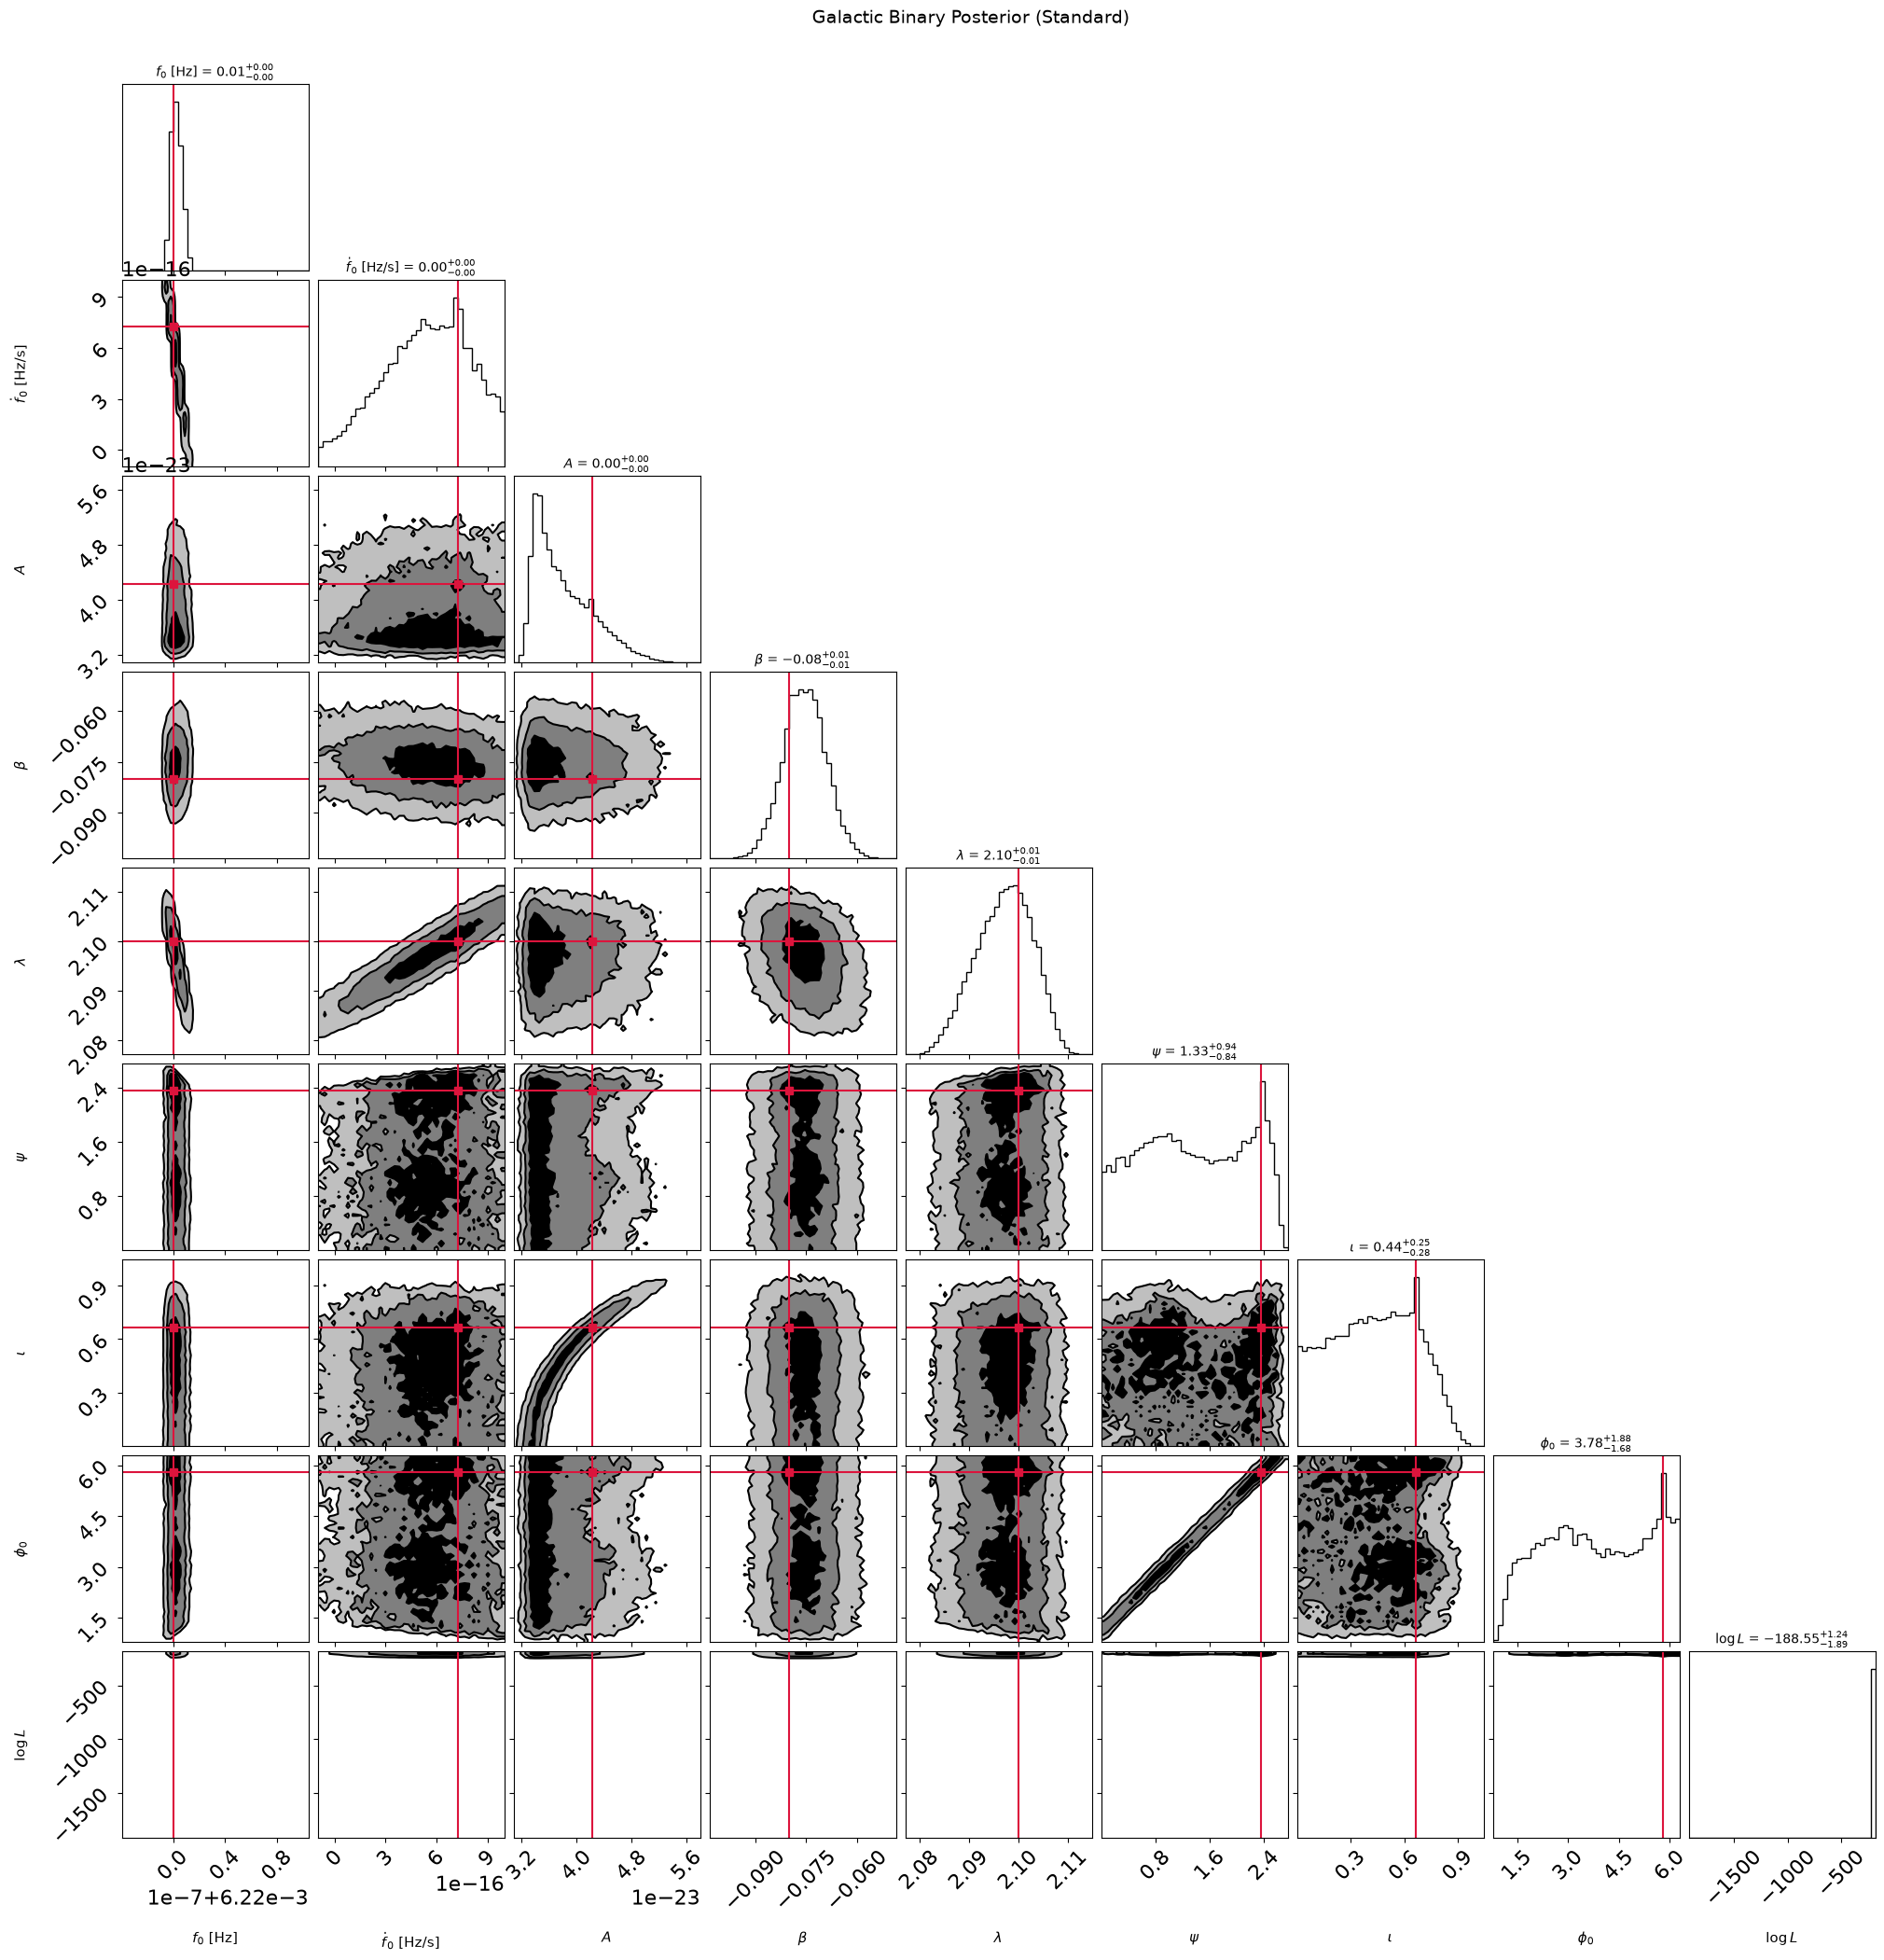

In [16]:
labels_full = np.array(get_parameter_labels(use_transformed=USE_TRANSFORMED_PARAMS) + [r"$\log L$"])
truths_full = np.append(true_sampling_params, np.nan)

temperature_index = 0  # Coldest chain

discard = 0
chain = sampler.get_chain(discard=discard)["gb"]  # expected: (steps, temps, walkers, 1, ndim)
logl = sampler.get_log_like(discard=discard)

# cold chain (temperature index 0), flatten walkers + iterations
cold_samples = chain[:, temperature_index].reshape(-1, chain.shape[-1])
cold_logl = logl[:, temperature_index].reshape(-1, 1)

samp_log = np.hstack((cold_samples, cold_logl))

# --- Summary Statistics Table ---
med = np.median(cold_samples, axis=0)
std = np.std(cold_samples, axis=0)

print(f"\n{'Parameter':<18} | {'Median':<18} | {'Std':<12} | {'Precision':<10} | {'Bias':<12} | {'Bias (sigma)'}")
print("-" * 100)
for i, lbl in enumerate(labels_full[:-1]):
    den = true_sampling_params[i]
    prec = np.nan if (not np.isfinite(den) or den == 0) else std[i] / np.abs(den)
    bias = med[i] - true_sampling_params[i]
    bias_sig = bias / std[i] if std[i] > 0 else np.nan
    print(f"{lbl:<18} | {med[i]:<18.10e} | {std[i]:<12.4e} | {prec:<10.2e} | {bias:<12.4e} | {bias_sig:+.2f}")

# --- Standardized Corner Plot Configuration ---
CORNER_KWARGS = dict(
    bins=40,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.0)),
    plot_density=True,
    plot_datapoints=False,
    fill_contours=True,
    show_titles=True,
    title_kwargs=dict(fontsize=10),
    max_n_ticks=4,
    truth_color="crimson",
    labelpad=0.2,
    label_kwargs=dict(fontsize=11),
)

fig = corner.corner(
    samp_log,
    labels=labels_full.tolist(),
    truths=truths_full,
    **CORNER_KWARGS,
)
fig.suptitle(f"Galactic Binary Posterior ({'Transformed' if USE_TRANSFORMED_PARAMS else 'Standard'})", fontsize=14, y=1.02)
plt.show()


Do we recover all degeneracies? Why or why not?

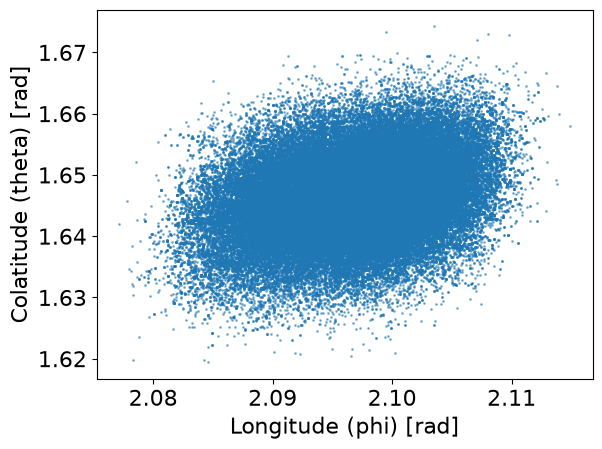

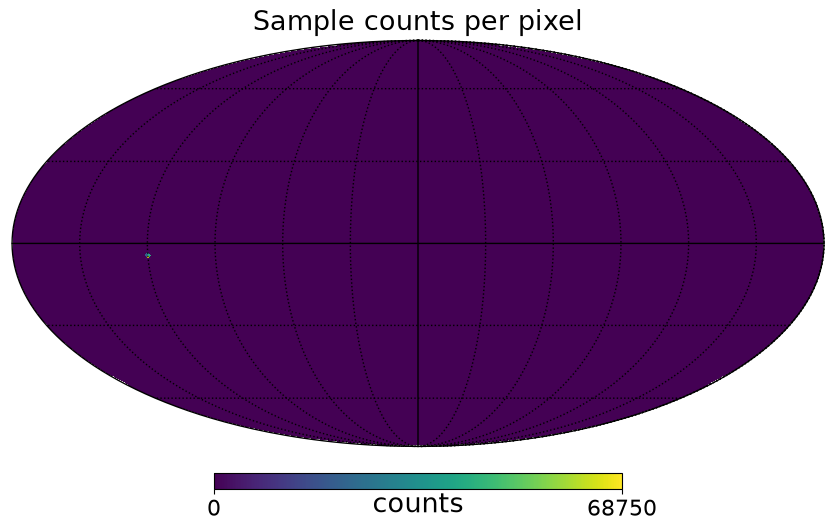

In [17]:
# Extract samples for sky localization
if USE_TRANSFORMED_PARAMS:
    beta = np.arcsin(np.clip(cold_samples[:, 3], -1.0, 1.0))
else:
    beta = cold_samples[:, 3]
lam = cold_samples[:, 4]

# HEALPix convention:
# theta = colatitude in [0, pi]
# phi   = longitude in [0, 2*pi]
theta = np.pi/2 - beta
phi = lam

plt.plot(phi, theta, 'o', markersize=1, alpha=0.5)
plt.xlabel("Longitude (phi) [rad]")
plt.ylabel("Colatitude (theta) [rad]")

# Choose resolution
nside = 64
npix = hp.nside2npix(nside)

# Assign each sample to a pixel
pix = hp.ang2pix(nside, theta, phi)

# Count samples per pixel
hmap = np.bincount(pix, minlength=npix)

# Convert to probability density if desired
prob_map = hmap / hmap.sum()

# HEALPix Mollweide count map
hp.mollview(
    hmap,
    title="Sample counts per pixel",
    unit="counts",
    norm=None,
    cmap="viridis"
)
hp.graticule()

plt.show()


# Joint Signal and Noise Inference: Diagonal Per-Channel Noise Fit

Previously, we assumed that the instrumental noise Power Spectral Density $S_{n,X}(f)$ was known exactly and fixed. In realistic data analysis, the true instrumental noise levels may have calibration uncertainties or depart from nominal models.

In this section, we test a **joint parameter estimation** of both the binary parameters and the noise level. We fit the data using a simplified, frequency-flat Gaussian noise model parameterized by independent per-channel bin noise standard deviations $\boldsymbol{\sigma} = (\sigma_A, \sigma_E, \sigma_T)$:

$$\mathbf{Cov}_{\rm model} = \mathrm{diag}(\sigma_A^2, \sigma_E^2, \sigma_T^2)$$

The 3 noise sigmas are sampled simultaneously alongside the 8 GB parameters (11 dimensions total). The corresponding circular complex Gaussian log-likelihood is:

$$\ln \mathcal{L}(\boldsymbol{\theta}, \boldsymbol{\sigma}) = -\sum_{X \in \{A, E, T\}} \left[ N_{\rm freq} \ln(\pi \sigma_X^2) + \frac{\sum_k |\tilde{r}_X(f_k; \boldsymbol{\theta})|^2}{\sigma_X^2} \right]$$

$\sigma_X$ are now free parameters. Therefore, a normalization term $-N_{\rm freq} \ln(\pi \sigma_X^2)$ must be included. It acts as a penalty that balances the residual sum of squares, preventing the likelihood from artificially diverging $\sigma_X \to \infty$.

In [18]:
NWALKERS_DIAG, NTEMPS_DIAG = 32, 8
BATCH_SIZE_DIAG = NTEMPS_DIAG * NWALKERS_DIAG
d_noisy_batch_diag = jnp.repeat(jnp.asarray(d_noisy)[None, :, :], BATCH_SIZE_DIAG, axis=0)

# Consistency check: normalized inner product of noise-only realization (should be ~1 for 3 channels * N_FREQ_BINS)
noise_inner_check = inner_product(d_noise_only, d_noise_only, inv_psd_AET_diag) / (3 * N_FREQ_BINS)
print(f"Normalized noise inner product check: {noise_inner_check:.3f} (expected ~ 1.0)")


Normalized noise inner product check: 0.973 (expected ~ 1.0)


In [19]:
USE_TRANSFORMED_PARAMS_DIAG = False

def diag_log_likelihood(params, data, kmin, kmax, tdi_generation, tdi_combination, use_transformed=False):
    """
    params: (..., 11) = [f0, fdot, A_or_lnA, beta_or_sin, lambda, psi, iota_or_cos, phi0, sigma_A, sigma_E, sigma_T]
    data:   (..., 3, n_freq) complex, same channel/freq layout as d_inj / d_noisy
    Cov = diag(sigma_A^2, sigma_E^2, sigma_T^2), constant across frequency -- a deliberately
    mismatched model relative to the true colored/cross-correlated cov_AET the noise was
    drawn from.
    """
    gb_params = params_to_physical(params[..., :8], use_transformed)
    sigma = params[..., 8:11] 

    residual = jaxgb.get_data_minus_template(
        gb_params, data, kmin, kmax,
        tdi_generation=tdi_generation, tdi_combination=tdi_combination,
    )

    n_freq = residual.shape[-1]
    resid_power = jnp.sum(jnp.abs(residual) ** 2, axis=-1)  # (..., 3)
    sigma2 = sigma ** 2

    return -jnp.sum(n_freq * jnp.log(jnp.pi * sigma2) + resid_power / sigma2, axis=-1)


@partial(jax.jit, static_argnames=("kmin", "kmax", "tdi_generation", "tdi_combination", "use_transformed"))
def jit_ll_diag(params, data, kmin, kmax, tdi_generation, tdi_combination, use_transformed=False):
    return diag_log_likelihood(params, data, kmin, kmax, tdi_generation, tdi_combination, use_transformed=use_transformed)


def eval_diag_ll(params_2d, use_transformed=False):
    params_2d = np.atleast_2d(params_2d)
    data_batch = jnp.repeat(jnp.asarray(d_noisy)[None, :, :], params_2d.shape[0], axis=0)
    return np.asarray(jit_ll_diag(jnp.asarray(params_2d), data_batch, kmin, kmax, 2.0, "AET", use_transformed=use_transformed))


In [20]:
def setup_priors_with_noise(f0_center, f0_width, sigma0, A_center=1e-18, use_transformed=False):
    """8 GB-parameter priors plus 3 per-channel diagonal noise-sigma priors (indices 8, 9, 10 = sigma_A, sigma_E, sigma_T)."""
    min_A, max_A = A_center / 4, A_center * 4
    fdot_min, fdot_max = -1e-16, 1e-15
    f_min, f_max = f0_center - f0_width, f0_center + f0_width

    sigma_lo, sigma_hi = 1/100, 5.0  # multiplicative bounds around sigma0; keeps sigma > 0
    sA0, sE0, sT0 = sigma0

    if use_transformed:
        priors_dict = {
            0: uniform_dist(f_min, f_max),
            1: uniform_dist(fdot_min, fdot_max),
            2: uniform_dist(np.log(min_A), np.log(max_A)),
            3: uniform_dist(-1.0, 1.0),
            4: uniform_dist(0.0, 2 * np.pi),
            5: uniform_dist(0.0, 2 * np.pi),
            6: uniform_dist(-1.0, 1.0),
            7: uniform_dist(0.0, 2 * np.pi),
            8: uniform_dist(sigma_lo * sA0, sigma_hi * sA0),
            9: uniform_dist(sigma_lo * sE0, sigma_hi * sE0),
            10: uniform_dist(sigma_lo * sT0, sigma_hi * sT0),
        }
        bounds = [
            (f_min, f_max), (fdot_min, fdot_max), (np.log(min_A), np.log(max_A)),
            (-1.0, 1.0), (0.0, 2 * np.pi), (0.0, 2 * np.pi), (-1.0, 1.0), (0.0, 2 * np.pi),
            (sigma_lo * sA0, sigma_hi * sA0), (sigma_lo * sE0, sigma_hi * sE0), (sigma_lo * sT0, sigma_hi * sT0),
        ]
    else:
        priors_dict = {
            0: uniform_dist(f_min, f_max),
            1: uniform_dist(fdot_min, fdot_max),
            2: uniform_dist(min_A, max_A),
            3: uniform_dist(-np.pi / 2, np.pi / 2),
            4: uniform_dist(0.0, 2 * np.pi),
            5: uniform_dist(0.0, 2 * np.pi),
            6: uniform_dist(0.0, np.pi),
            7: uniform_dist(0.0, 2 * np.pi),
            8: uniform_dist(sigma_lo * sA0, sigma_hi * sA0),
            9: uniform_dist(sigma_lo * sE0, sigma_hi * sE0),
            10: uniform_dist(sigma_lo * sT0, sigma_hi * sT0),
        }
        bounds = [
            (f_min, f_max), (fdot_min, fdot_max), (min_A, max_A),
            (-np.pi / 2, np.pi / 2), (0.0, 2 * np.pi), (0.0, 2 * np.pi), (0.0, np.pi), (0.0, 2 * np.pi),
            (sigma_lo * sA0, sigma_hi * sA0), (sigma_lo * sE0, sigma_hi * sE0), (sigma_lo * sT0, sigma_hi * sT0),
        ]

    priors = {"gb": ProbDistContainer(priors_dict)}
    periodic = {"gb": {4: 2 * np.pi, 5: 2 * np.pi, 7: 2 * np.pi}}
    return priors, periodic, 11, bounds


### Likelihood Sanity Checks (Diagonal Noise Model)

Before running the 11-dimensional MCMC, we perform four sanity checks on the joint likelihood:
1. **Analytic Expectation at Truth:** At the true parameters, the residual is the injected noise realization, so $\mathbb{E}[\sum_k |r_{X,k}|^2] \approx N_{\rm freq} \sigma_X^2$. The evaluated log-likelihood should match the analytic order of magnitude $\mathbb{E}[\ln\mathcal{L}] \approx -\sum_X N_{\rm freq} (\ln(\pi \sigma_{0,X}^2) + 1)$.
2. **Frequency Perturbation:** Offsetting $f_0$ by 20 bins should cause the log-likelihood to drop sharply, confirming parameter sensitivity.
3. **1D Likelihood Profile over $\sigma_A$:** Profiling over $\sigma_A$ while fixing other parameters should peak close to the empirical noise standard deviation of the injected draw.

Likelihood sanity checks (diagonal noise model)
log-likelihood at [true GB params, sigma0]: [29622.19152473]
analytic expectation (order-of-magnitude):   29611.92
log-likelihood 20 bins off in f0: [25620.74361032]  (should be < [29622.19152473] at truth)


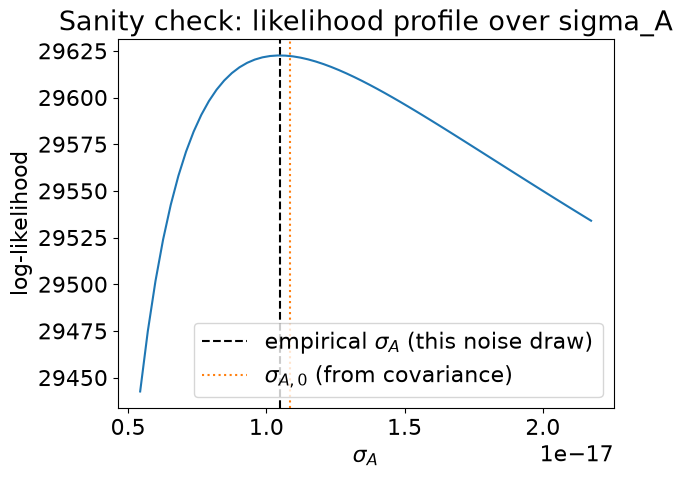


sigma_A maximizing the profiled likelihood: 1.041e-17
empirical sigma_A from the noise draw:      1.048e-17


In [21]:
print("=" * 60)
print("Likelihood sanity checks (diagonal noise model)")
print("=" * 60)

truth_ext = np.concatenate([
    physical_to_sampling(injection_source_params, use_transformed=USE_TRANSFORMED_PARAMS_DIAG),
    sigma0
])

# Evaluating at [true GB params, sigma0] and compare to a rough analytic expectation.
ll_truth = eval_diag_ll(truth_ext, use_transformed=USE_TRANSFORMED_PARAMS_DIAG)
ll_expected = -np.sum(N_FREQ_BINS * (np.log(np.pi * sigma0 ** 2) + 1))
print(f"log-likelihood at [true GB params, sigma0]: {ll_truth}")
print(f"analytic expectation (order-of-magnitude):   {ll_expected:.2f}")

# Perturbation check: moving f0 away from truth must make the fit strictly worse.
offset_params = truth_ext.copy()
offset_params[0] += 20 * DF  # shift by 20 frequency bins, well inside the prior/heterodyne window
ll_offset = eval_diag_ll(offset_params, use_transformed=USE_TRANSFORMED_PARAMS_DIAG)
print(f"log-likelihood 20 bins off in f0: {ll_offset}  (should be < {ll_truth} at truth)")

# 1D likelihood profile over sigma_A (GB params + sigma_E, sigma_T held at truth/sigma0)
sigma_A_grid = np.linspace(0.5 * sigma0[0], 2 * sigma0[0], 60)
grid_params = np.repeat(truth_ext[None, :], len(sigma_A_grid), axis=0)
grid_params[:, 8] = sigma_A_grid
ll_grid = eval_diag_ll(grid_params, use_transformed=USE_TRANSFORMED_PARAMS_DIAG)

plt.figure()
plt.plot(sigma_A_grid, ll_grid)
plt.axvline(sigma_empirical[0], color="k", linestyle="--", label=r"empirical $\sigma_A$ (this noise draw)")
plt.axvline(sigma0[0], color="C1", linestyle=":", label=r"$\sigma_{A,0}$ (from covariance)")
plt.xlabel(r"$\sigma_A$")
plt.ylabel("log-likelihood")
plt.legend()
plt.title("Sanity check: likelihood profile over sigma_A")
plt.show()

best_sigma_A = sigma_A_grid[np.argmax(ll_grid)]
print(f"\nsigma_A maximizing the profiled likelihood: {best_sigma_A:.3e}")
print(f"empirical sigma_A from the noise draw:      {sigma_empirical[0]:.3e}")


## Running Joint MCMC on GB Parameters + Channel Noise Sigmas

In [22]:
priors_ext, periodic_ext, ndims_ext, bounds_ext = setup_priors_with_noise(
    injection_source_params[0], 1e-6, sigma0, A_center=injection_source_params[2], use_transformed=USE_TRANSFORMED_PARAMS_DIAG
)

# temp_params buffer for the FIXED-shape MCMC path
temp_params_diag = np.zeros((BATCH_SIZE_DIAG, ndims_ext))

def likelihood_diag(params, data, temp_params, use_transformed=False):
    n = len(params)
    temp_params[:n] = params
    lls = jit_ll_diag(jnp.asarray(temp_params), data, kmin, kmax, 2.0, "AET", use_transformed=use_transformed)
    return np.asarray(lls[:n])

rand_draws = np.asarray(priors_ext["gb"].rvs(size=(1, BATCH_SIZE_DIAG, 1))).reshape(BATCH_SIZE_DIAG, ndims_ext)
_tic = time.time()
ll_test = likelihood_diag(np.asarray(rand_draws), d_noisy_batch_diag, temp_params_diag, use_transformed=USE_TRANSFORMED_PARAMS_DIAG)
print(f"jit_ll_diag compiled and warmed up in {time.time() - _tic:.2f} s")


jit_ll_diag compiled and warmed up in 0.24 s


In [23]:
sampler_diag = EnsembleSampler(
    NWALKERS_DIAG,
    ndims_ext,
    likelihood_diag,
    priors_ext,
    branch_names=["gb"],
    args=(d_noisy_batch_diag, temp_params_diag, USE_TRANSFORMED_PARAMS_DIAG),
    tempering_kwargs=dict(ntemps=NTEMPS_DIAG),
    periodic=periodic_ext,
    vectorize=True,
)

print("Initializing sampler state (GB + diagonal noise sigmas)...")
start_points_diag = {
    "gb": np.zeros((NTEMPS_DIAG, NWALKERS_DIAG, 1, ndims_ext))
}
start_inds_diag = {
    "gb": np.ones((NTEMPS_DIAG, NWALKERS_DIAG, 1), dtype=bool)
}

# Start all parameters (8 GB params + 3 noise sigmas) around the truth across all temperatures and walkers
rel_scatter = 1e-4

for par_i in range(ndims_ext):
    truth_val = truth_ext[par_i]
    if par_i == 0:
        # Keep scatter safely inside the narrow frequency prior window (1 uHz width)
        scale_i = min(rel_scatter, 1e-5) * np.abs(truth_val)
    elif USE_TRANSFORMED_PARAMS_DIAG and par_i in [2, 3, 6]:
        scale_i = rel_scatter if np.abs(truth_val) < 1.0 else rel_scatter * np.abs(truth_val)
    else:
        scale_i = rel_scatter * np.abs(truth_val) if truth_val != 0 else rel_scatter

    draws = np.random.normal(loc=truth_val, scale=scale_i, size=(NTEMPS_DIAG, NWALKERS_DIAG))
    lo, hi = bounds_ext[par_i]
    margin = 1e-5 * (hi - lo)
    draws = np.clip(draws, lo + margin, hi - margin)
    start_points_diag["gb"][:, :, 0, par_i] = draws

start_state_diag = State(start_points_diag)

lp_diag = sampler_diag.compute_log_prior(start_state_diag.branches_coords)
start_state_diag.log_prior = lp_diag

ll_diag0 = sampler_diag.compute_log_like(start_state_diag.branches_coords, logp=lp_diag, inds=start_inds_diag)
start_state_diag.log_like = ll_diag0[0]
print(f"Initial log-likelihood range: [{ll_diag0[0].min():.2f}, {ll_diag0[0].max():.2f}]")

tic = time.time()
_ = sampler_diag.compute_log_like(start_state_diag.branches_coords, logp=lp_diag)
toc = time.time()
print(f"Likelihood evaluation time: {(toc - tic) * 1000:.2f} ms")

n_iterations = 5000
print(f"Running {n_iterations} iterations (GB params + diagonal AET noise sigmas)...")
sampler_diag.run_mcmc(start_state_diag, n_iterations, progress=True, burn=0)

print("\n" + "=" * 60)
print("MCMC (noise-mismatched analysis) complete!")
print("=" * 60)

Initializing sampler state (GB + diagonal noise sigmas)...
Initial log-likelihood range: [24036.03, 29618.10]
Likelihood evaluation time: 2.74 ms
Running 5000 iterations (GB params + diagonal AET noise sigmas)...


100%|██████████| 5000/5000 [00:31<00:00, 160.89it/s]


MCMC (noise-mismatched analysis) complete!



Parameter          | Median             | Std          | Precision  | Bias         | Bias (sigma)
-------------------------------------------------------------------------------------
$f_0$ [Hz]         | 6.2200019654e-03   | 3.2930e-09   | 5.29e-07   | 1.9654e-09   | +0.60
$\dot f_0$ [Hz/s]  | 5.6419953055e-16   | 2.0642e-16   | 2.85e-01   | -1.6080e-16  | -0.78
$A$                | 3.6840146404e-23   | 3.6796e-24   | 8.72e-02   | -5.3599e-24  | -1.46
$\beta$            | -7.5861209741e-02  | 4.4510e-03   | 5.56e-02   | 4.1388e-03   | +0.93
$\lambda$          | 2.0975843953e+00   | 4.4770e-03   | 2.13e-03   | -2.4156e-03  | -0.54
$\psi$             | 1.4629521376e+00   | 7.6455e-01   | 3.25e-01   | -8.8705e-01  | -1.16
$\iota$            | 4.3139117653e-01   | 2.2020e-01   | 3.32e-01   | -2.3161e-01  | -1.05
$\phi_0$           | 4.0390521569e+00   | 1.5207e+00   | 2.63e-01   | -1.7509e+00  | -1.15
$\sigma_A$         | 1.0560004327e-17   | 4.7869e-19   | 4.40e-02   | -3.1264e-19  | -0

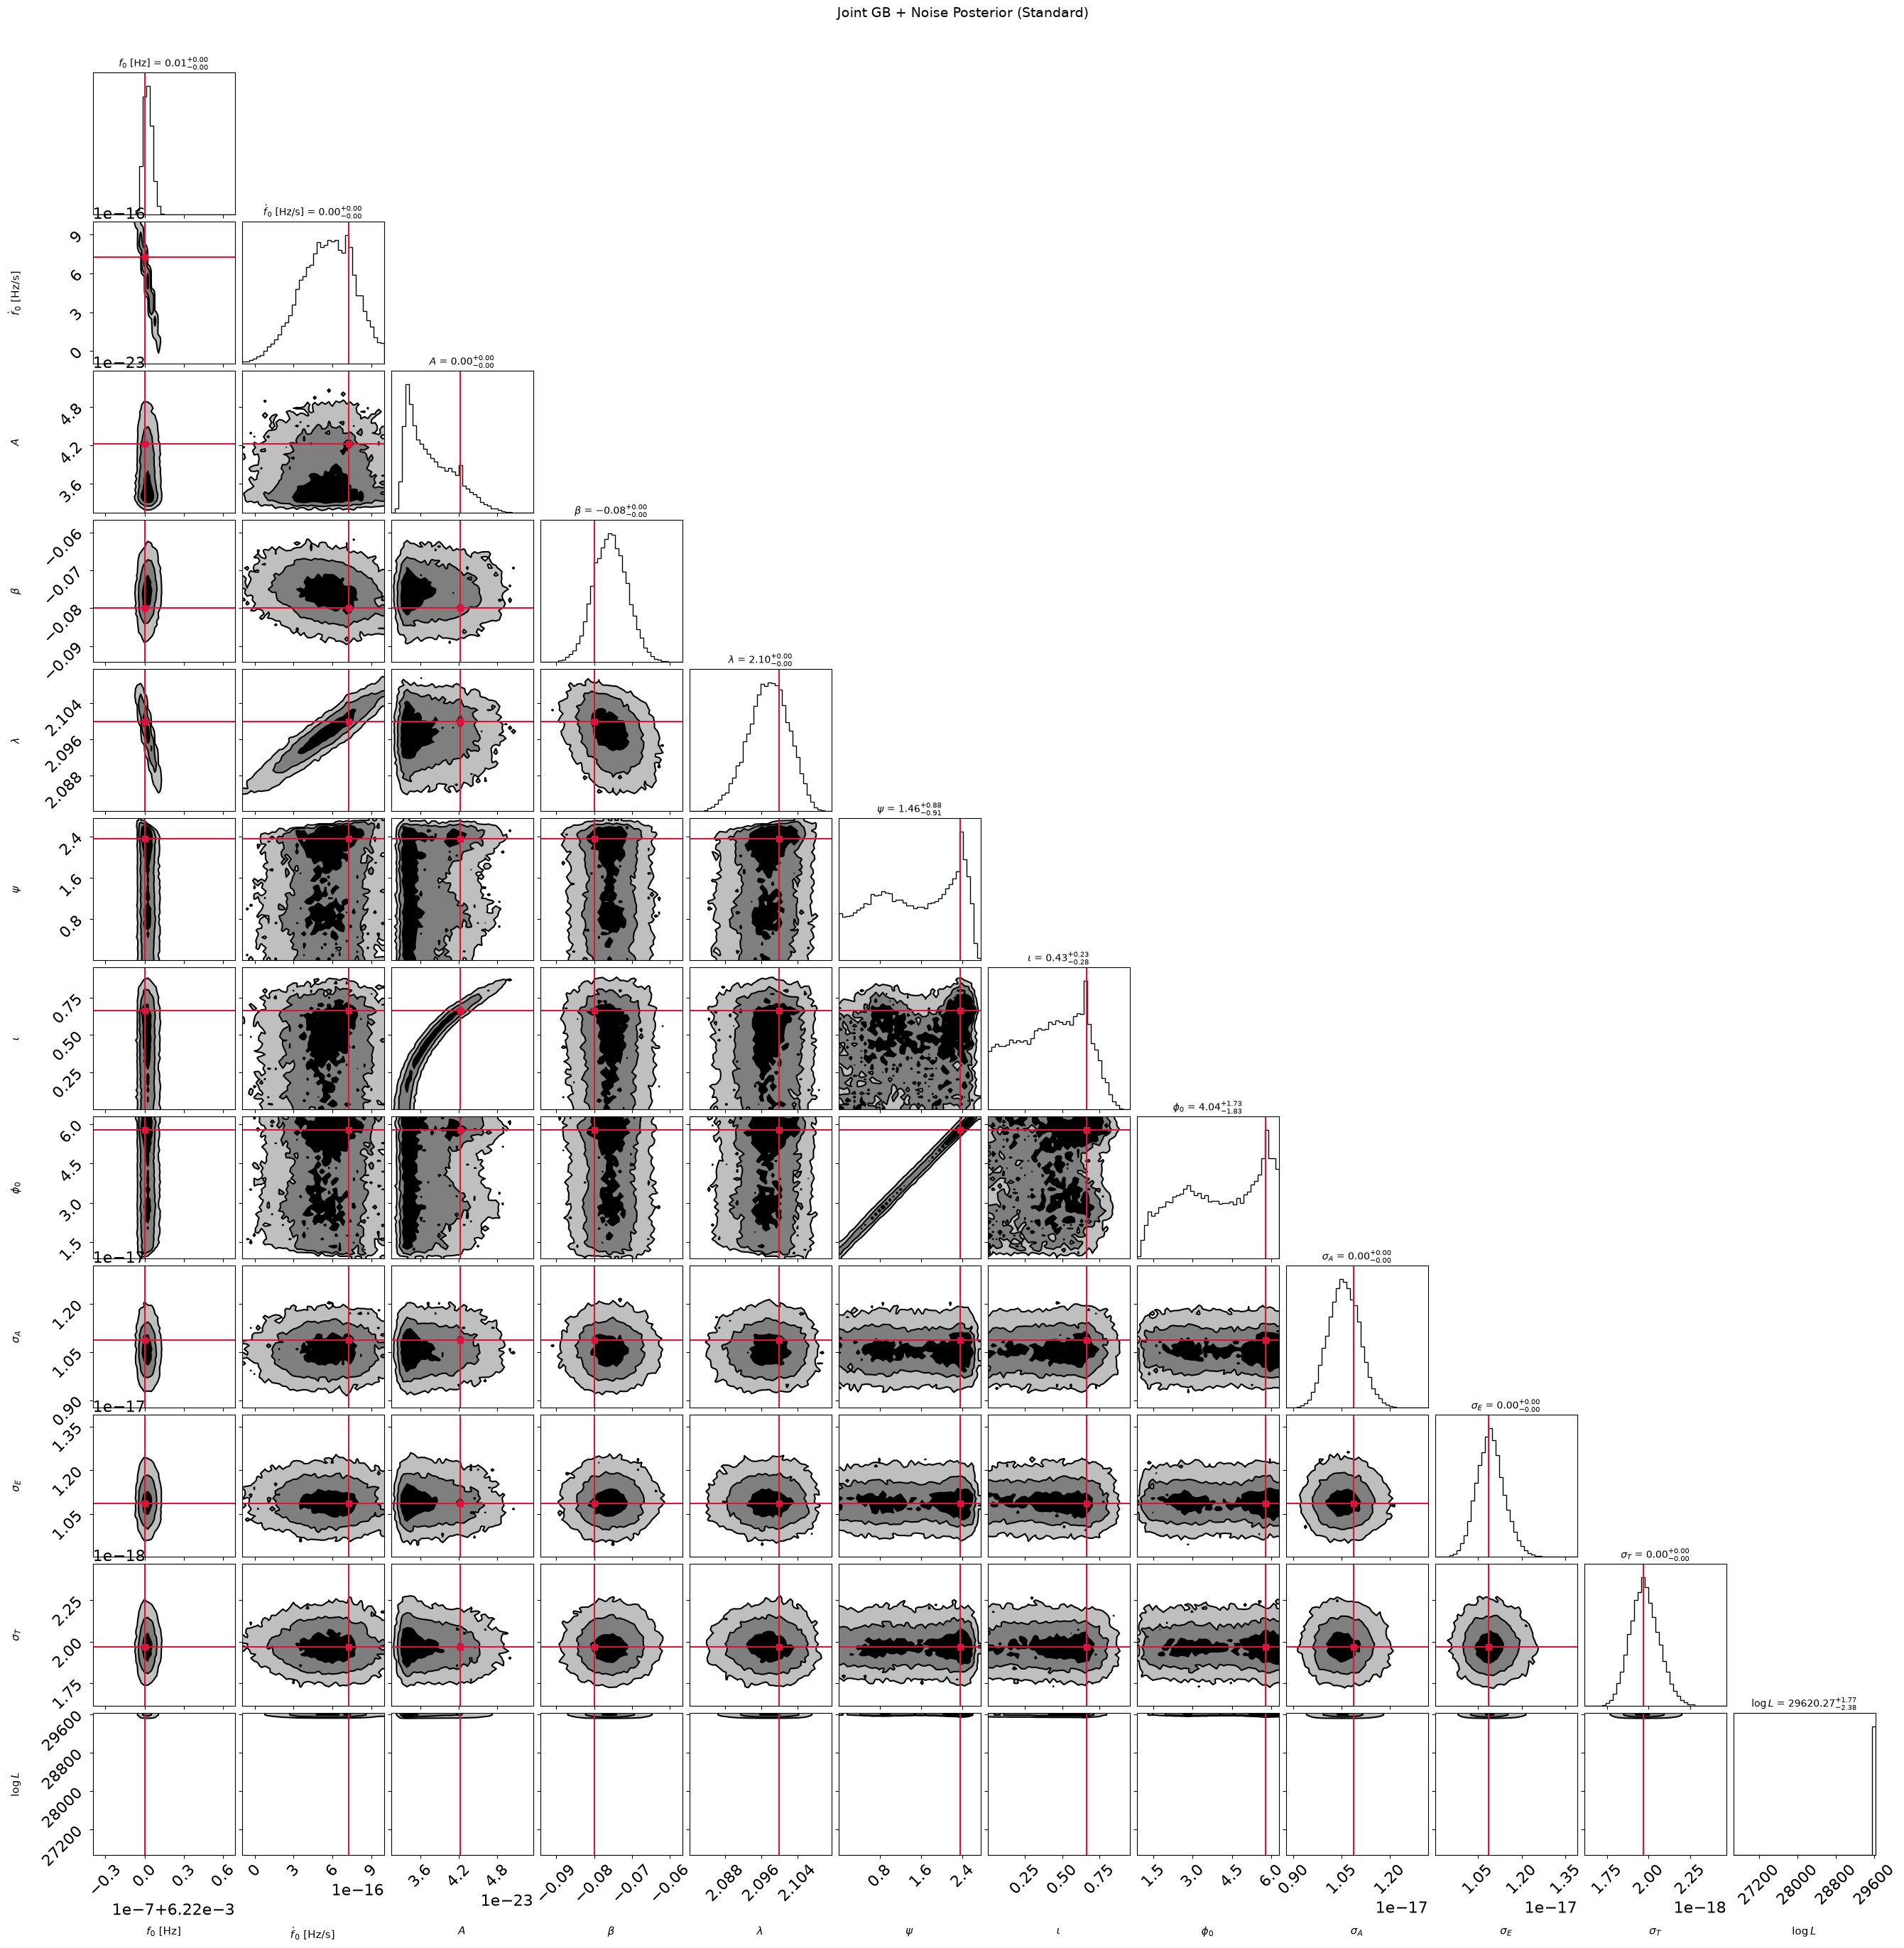

In [24]:
labels_ext = np.array(get_parameter_labels(use_transformed=USE_TRANSFORMED_PARAMS_DIAG, include_noise=True) + [r"$\log L$"])
truths_ext = np.append(truth_ext, np.nan)

discard = 0
chain_diag = sampler_diag.get_chain(discard=discard)["gb"][:, 0, :, 0, :]  # coldest temp, single leaf -> (nsteps, nwalkers, ndim)
samples_diag = np.asarray(chain_diag).reshape(-1, ndims_ext)

loglike = sampler_diag.get_log_like(discard=discard)[:, 0, :]  # coldest temp, single leaf -> (nsteps, nwalkers)
loglike = np.asarray(loglike).reshape(-1, 1)

to_corner = np.concatenate([samples_diag, loglike], axis=1)

# --- Summary Statistics Table ---
med_diag = np.median(samples_diag, axis=0)
std_diag = np.std(samples_diag, axis=0)

print(f"\n{'Parameter':<18} | {'Median':<18} | {'Std':<12} | {'Precision':<10} | {'Bias':<12} | {'Bias (sigma)'}")
print("-" * 85)
for i, lbl in enumerate(labels_ext[:-1]):
    den = truth_ext[i]
    prec = np.nan if (not np.isfinite(den) or den == 0) else std_diag[i] / np.abs(den)
    bias = med_diag[i] - truth_ext[i]
    bias_sig = bias / std_diag[i] if std_diag[i] > 0 else np.nan
    print(f"{lbl:<18} | {med_diag[i]:<18.10e} | {std_diag[i]:<12.4e} | {prec:<10.2e} | {bias:<12.4e} | {bias_sig:+.2f}")

# Full 11-parameter + logL corner plot
fig = corner.corner(
    to_corner,
    labels=labels_ext.tolist(),
    truths=truths_ext,
    **CORNER_KWARGS,
)
fig.suptitle(f"Joint GB + Noise Posterior ({'Transformed' if USE_TRANSFORMED_PARAMS_DIAG else 'Standard'})", fontsize=14, y=1.02)
plt.show()


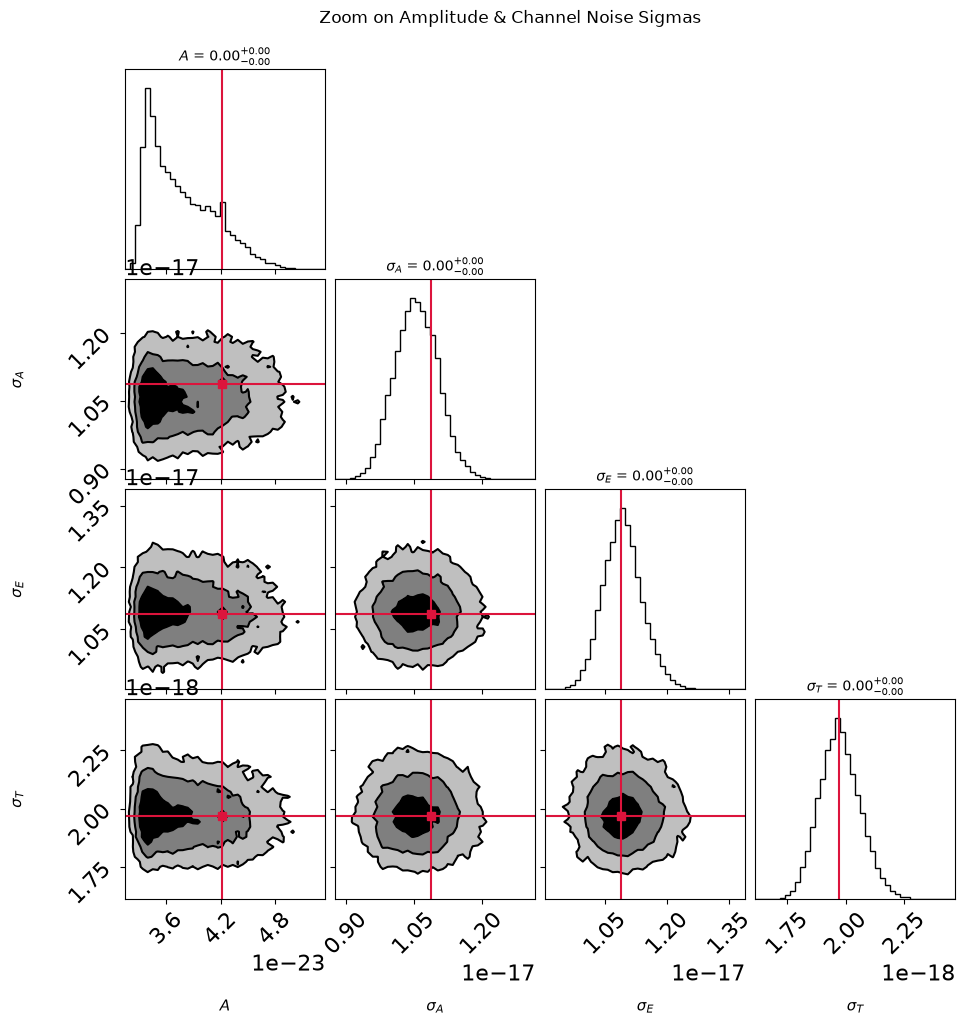

In [25]:
# Focused corner plot: amplitude & channel noise sigmas
ind_show = np.array([2, 8, 9, 10], dtype=int)  # A (or lnA), sigma_A, sigma_E, sigma_T
fig = corner.corner(
    to_corner[:, ind_show],
    labels=labels_ext[ind_show].tolist(),
    truths=truths_ext[ind_show],
    **CORNER_KWARGS,
)
fig.suptitle("Zoom on Amplitude & Channel Noise Sigmas", fontsize=12, y=1.02)
plt.show()


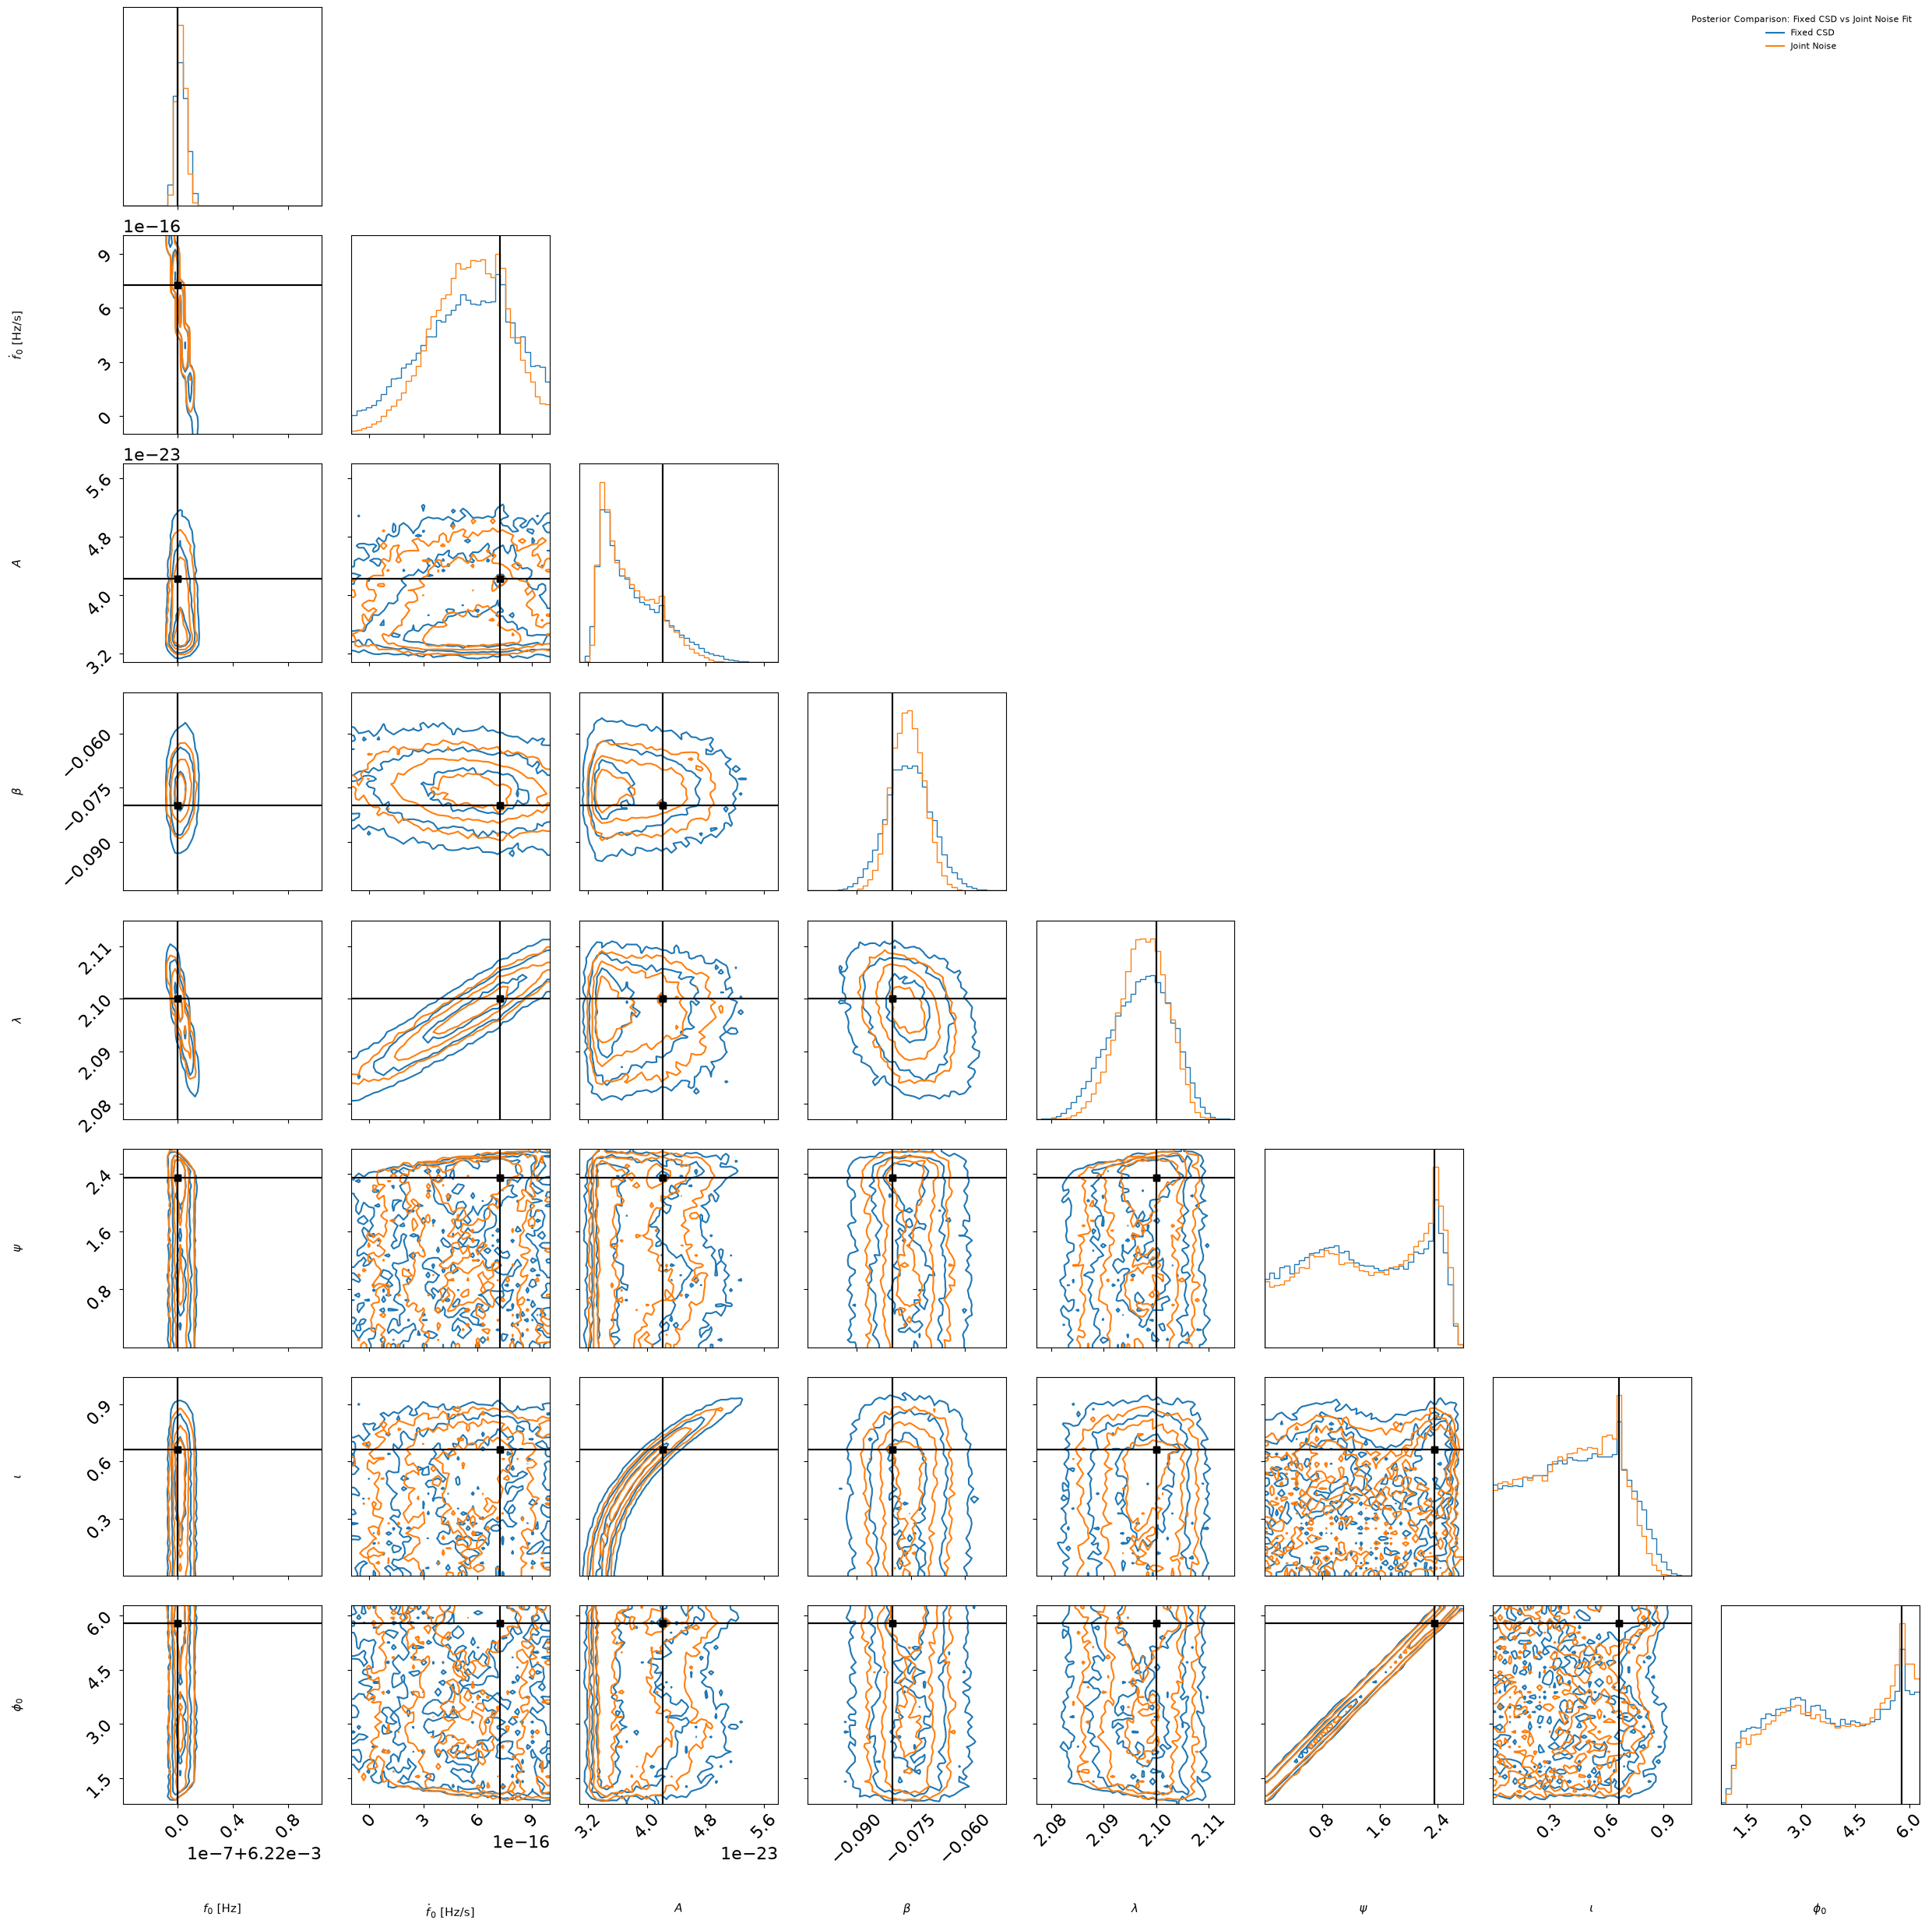

In [26]:
# Comparison: fixed CSD vs joint noise fit on common 8 GB parameters
if "cold_samples" in globals():
    labels_gb = get_parameter_labels(use_transformed=USE_TRANSFORMED_PARAMS)
    truths_gb = true_sampling_params[:8]

    CORNER_KWARGS_OVERLAY = dict(
        labels=labels_gb,
        truths=truths_gb,
        bins=40,
        levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.0)),
        plot_density=False,
        plot_datapoints=False,
        fill_contours=False,
        max_n_ticks=4,
        truth_color="k",
        labelpad=0.2,
        label_kwargs=dict(fontsize=11),
    )

    overlaid_corner(
        samples_list=[cold_samples[:, :8], samples_diag[:, :8]],
        sample_labels=["Fixed CSD", "Joint Noise"],
        name_save=None,
        corn_kw=CORNER_KWARGS_OVERLAY,
        title="Posterior Comparison: Fixed CSD vs Joint Noise Fit",
    )
    plt.show()
else:
    print("Fixed CSD samples not found in session; run fixed CSD sampling first to generate the overlaid comparison plot.")


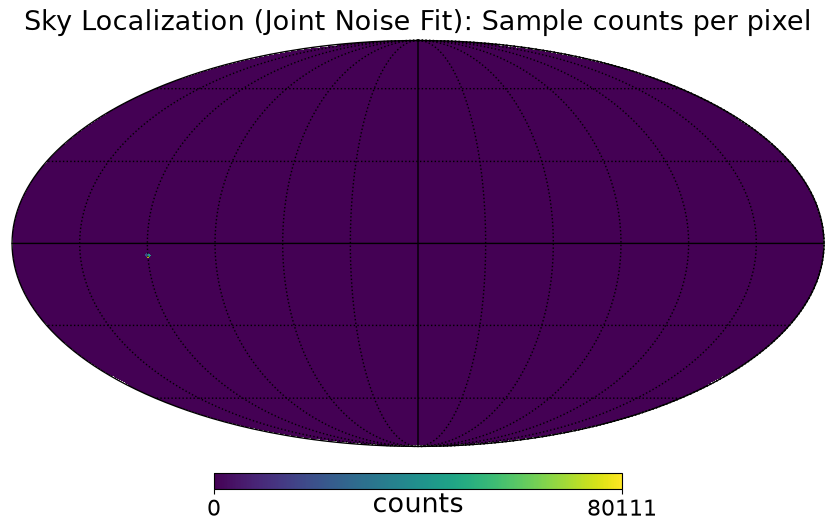

In [27]:
# Sky Localization for joint fit (HEALPix)
if USE_TRANSFORMED_PARAMS_DIAG:
    beta_diag = np.arcsin(np.clip(samples_diag[:, 3], -1.0, 1.0))
else:
    beta_diag = samples_diag[:, 3]
lam_diag = samples_diag[:, 4]

theta_diag = np.pi/2 - beta_diag
phi_diag = lam_diag

pix_diag = hp.ang2pix(nside, theta_diag, phi_diag)
hmap_diag = np.bincount(pix_diag, minlength=npix)

hp.mollview(
    hmap_diag,
    title="Sky Localization (Joint Noise Fit): Sample counts per pixel",
    unit="counts",
    norm=None,
    cmap="viridis",
)
hp.graticule()
plt.show()
